# Proyecto de Inteligencia Artificial Grupo 1

## Preprocesamiento de Heart Failure dataset

## Descripción del dataset:

- Este dataset se construyó combinando 5 datasets que comparten 11 features comunes — Cleveland (303 obs.), Hungarian (294), Switzerland (123), Long Beach VA (200) y Statlog/Heart (270), total 1190 observaciones, de las cuales 272 eran duplicadas, quedando solo 918 registros únicos.

- Las definiciones de las variables vienen de los datasets originales antes mencionas de la UCI (donados por los hospitales de Hungría, Zúrich, Basilea, Long Beach y Cleveland).

Fuente: fedesoriano. (September 2021). Heart Failure Prediction Dataset.
https://www.kaggle.com/fedesoriano/heart-failure-prediction

---

### Variables predictoras

**1. Age** — *Numérica (int)*
Edad del paciente expresada en años.
- Rango en el dataset: 28 – 77 años
- Media: 53.51 | Mediana: 54

**2. Sex** — *Categórica (str)*
Sexo biológico del paciente.
- M: Masculino → 725 registros
- F: Femenino  → 193 registros

**3. ChestPainType** — *Categórica (str)*
Tipo de dolor torácico reportado por el paciente.
- TA  (Typical Angina)    → Angina típica              →  46 registros
- ATA (Atypical Angina)   → Angina atípica             → 173 registros
- NAP (Non-Anginal Pain)  → Dolor no anginoso          → 203 registros
- ASY (Asymptomatic)      → Asintomático               → 496 registros

**4. RestingBP** — *Numérica (int)*
Presión arterial en reposo, medida en mm Hg.
- Rango en el dataset: 0 – 200 mm Hg
- Media: 132.40 | Mediana: 130
-  1 registro presenta valor 0 (fisiológicamente imposible → dato faltante enmascarado)

**5. Cholesterol** — *Numérica (int)*
Nivel de colesterol sérico, medido en mg/dl.
- Rango en el dataset: 0 – 603 mg/dl
- Media: 198.80 | Mediana (valores válidos >0): 223
-  172 registros presentan valor 0 (fisiológicamente imposible → dato faltante enmascarado,
  principalmente heredados del subset de Suiza)

**6. FastingBS** — *Binaria (int)*
Nivel de glucemia en ayunas.
- 1: Glucemia en ayunas > 120 mg/dl → 211 registros
- 0: Glucemia en ayunas ≤ 120 mg/dl → 707 registros

**7. RestingECG** — *Categórica (str)*
Resultado del electrocardiograma en reposo.
- Normal → Electrocardiograma normal                                          → 552 registros
- ST     → Anomalía de onda ST-T (inversión de onda T y/o elevación o
           depresión del segmento ST > 0.05 mV)                              → 178 registros
- LVH    → Hipertrofia ventricular izquierda probable o definida
           por criterios de Estes                                             → 188 registros

**8. MaxHR** — *Numérica (int)*
Frecuencia cardíaca máxima alcanzada durante la prueba de esfuerzo, en lpm.
- Rango en el dataset: 60 – 202 lpm
- Media: 136.81 | Mediana: 138

**9. ExerciseAngina** — *Categórica (str)*
Indica si el paciente presentó angina inducida por ejercicio.
- Y: Sí → 371 registros
- N: No → 547 registros

**10. Oldpeak** — *Numérica (float)*
Depresión (o elevación) del segmento ST inducida por el ejercicio,
medida en relación al reposo (valor numérico en mm).
- Rango en el dataset: -2.6 – 6.2
- Media: 0.89 | Mediana: 0.6
- Nota: valores negativos indican elevación del ST y son clínicamente válidos;
  no se tratan como errores.

**11. ST_Slope** — *Categórica (str)*
Pendiente del segmento ST en el pico del ejercicio.
- Up   → Pendiente ascendente → 395 registros
- Flat → Pendiente plana      → 460 registros
- Down → Pendiente descendente →  63 registros

---

### Variable objetivo

**HeartDisease** — *Binaria (int)*
Clase de salida: indica la presencia o ausencia de enfermedad cardíaca.
- 1: Presencia de enfermedad cardíaca → 508 registros (55.3%)
- 0: Ausencia de enfermedad cardíaca  → 410 registros (44.7%)

El dataset presenta un leve desbalance de clases (55.3% / 44.7%),
manejado mediante validación cruzada estratificada (StratifiedKFold, k=5)
para preservar esta proporción en cada fold.

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

In [2]:
import matplotlib.patches as mpatches
from sklearn.compose     import ColumnTransformer
from sklearn.pipeline    import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score)
from sklearn.linear_model  import LogisticRegression
from sklearn.svm           import SVC
from sklearn.ensemble      import RandomForestClassifier
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.metrics       import (accuracy_score, balanced_accuracy_score,
                                   confusion_matrix, classification_report)
from sklearn.base import clone
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

##Análisis preliminar del dataset:

In [3]:
url = "https://raw.githubusercontent.com/matias1205/heart-failure-prediction-ml/refs/heads/main/data/heart.csv"
df = pd.read_csv(url)

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
print('=' * 55)
print('TIPOS DE DATOS')
print('=' * 55)
print(df.dtypes)

print('\n' + '=' * 55)
print('VALORES NULOS POR COLUMNA')
print('=' * 55)
print(df.isnull().sum())

print('\n' + '=' * 55)
print('FILAS DUPLICADAS')
print('=' * 55)
print(f'Duplicados exactos: {df.duplicated().sum()}')

print('\n' + '=' * 55)
print('ESTADÍSTICAS DESCRIPTIVAS')
print('=' * 55)
df.describe().T

TIPOS DE DATOS
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

VALORES NULOS POR COLUMNA
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

FILAS DUPLICADAS
Duplicados exactos: 0

ESTADÍSTICAS DESCRIPTIVAS


,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


- No hay valores nulos
- Colesterol tiene valores iguales a 0 (Posiblemente un dato faltante de la fuente original)
- RestingB tiene un registro con valor igual a 0 cosa que no es posiible.

Revisión valores en los features

In [5]:
print('=' * 55)
print('REVISIÓN DE INCONSISTENCIAS POR FEATURE')
print('=' * 55)

# --- Numéricas ---
checks = {
    'Age'         : (df['Age'] < 0)          | (df['Age'] > 120),
    'RestingBP'   : (df['RestingBP'] <= 0)   | (df['RestingBP'] > 300),
    'Cholesterol' : (df['Cholesterol'] < 0)  | (df['Cholesterol'] > 700),
    'FastingBS'   : ~df['FastingBS'].isin([0, 1]),
    'MaxHR'       : (df['MaxHR'] < 40)       | (df['MaxHR'] > 250),
    'Oldpeak'     : (df['Oldpeak'] < -4)     | (df['Oldpeak'] > 10),
}

for feat, mask in checks.items():
    n = mask.sum()
    status = 'Sin problemas' if n == 0 else f'{n} registros fuera de rango'
    print(f'  {feat:15s}: {status}')

print()

# Caso especial: Cholesterol = 0 (imposible fisiológicamente)
n_chol0 = (df['Cholesterol'] == 0).sum()
n_bp0   = (df['RestingBP']   == 0).sum()
n_old_neg = (df['Oldpeak'] < 0).sum()

print(f'  Cholesterol == 0 : {n_chol0} registros  ← dato faltante enmascarado')
print(f'  RestingBP   == 0 : {n_bp0}  registro   ← dato faltante enmascarado')
print(f'  Oldpeak     <  0 : {n_old_neg} registros  ← clínicamente válidos (elevación ST)')

# --- Categóricas ---
print()
cat_valid = {
    'Sex'            : ['M', 'F'],
    'ChestPainType'  : ['TA', 'ATA', 'NAP', 'ASY'],
    'RestingECG'     : ['Normal', 'ST', 'LVH'],
    'ExerciseAngina' : ['Y', 'N'],
    'ST_Slope'       : ['Up', 'Flat', 'Down'],
}

for feat, valid_vals in cat_valid.items():
    invalid = ~df[feat].isin(valid_vals)
    n = invalid.sum()
    status = 'Sin problemas' if n == 0 else f'{n} valores inesperados'
    print(f'  {feat:16s}: {status}  |  Valores únicos: {sorted(df[feat].unique())}')

REVISIÓN DE INCONSISTENCIAS POR FEATURE
  Age            : Sin problemas
  RestingBP      : 1 registros fuera de rango
  Cholesterol    : Sin problemas
  FastingBS      : Sin problemas
  MaxHR          : Sin problemas
  Oldpeak        : Sin problemas

  Cholesterol == 0 : 172 registros  ← dato faltante enmascarado
  RestingBP   == 0 : 1  registro   ← dato faltante enmascarado
  Oldpeak     <  0 : 13 registros  ← clínicamente válidos (elevación ST)

  Sex             : Sin problemas  |  Valores únicos: ['F', 'M']
  ChestPainType   : Sin problemas  |  Valores únicos: ['ASY', 'ATA', 'NAP', 'TA']
  RestingECG      : Sin problemas  |  Valores únicos: ['LVH', 'Normal', 'ST']
  ExerciseAngina  : Sin problemas  |  Valores únicos: ['N', 'Y']
  ST_Slope        : Sin problemas  |  Valores únicos: ['Down', 'Flat', 'Up']


Valores que imputar o eliminar:
- RestingBP y Cholesterol.

Los demás features tienen valores dentro de lo esperado.

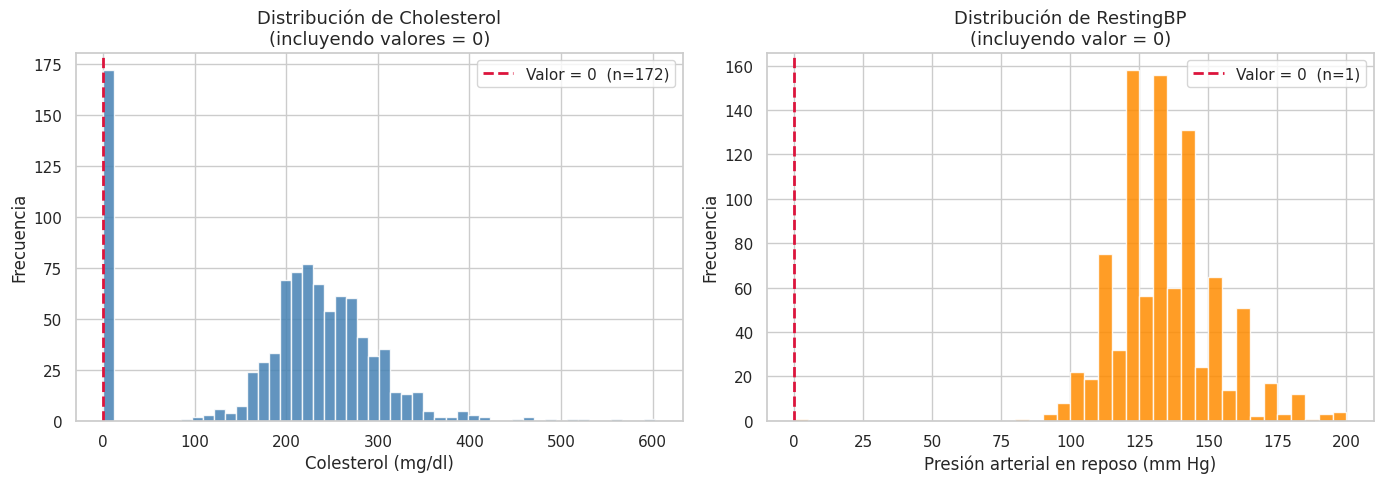

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Colesterol ---
ax = axes[0]
ax.hist(df['Cholesterol'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='crimson', linewidth=2, linestyle='--', label=f'Valor = 0  (n={n_chol0})')
ax.set_title('Distribución de Cholesterol\n(incluyendo valores = 0)', fontsize=13)
ax.set_xlabel('Colesterol (mg/dl)')
ax.set_ylabel('Frecuencia')
ax.legend()

# --- RestingBP ---
ax = axes[1]
ax.hist(df['RestingBP'], bins=40, color='darkorange', edgecolor='white', alpha=0.85)
ax.axvline(0, color='crimson', linewidth=2, linestyle='--', label=f'Valor = 0  (n={n_bp0})')
ax.set_title('Distribución de RestingBP\n(incluyendo valor = 0)', fontsize=13)
ax.set_xlabel('Presión arterial en reposo (mm Hg)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

In [7]:
df_clean = df.copy()

# ------------------------------------------------------------------
# 1. Cholesterol = 0  →  imputar con la mediana de valores válidos
#    (se excluyen los ceros para no sesgar la mediana)
# ------------------------------------------------------------------
median_chol = df_clean.loc[df_clean['Cholesterol'] > 0, 'Cholesterol'].median()
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, median_chol)

print(f'Cholesterol: mediana de valores válidos = {median_chol:.1f} mg/dl')
print(f'  Registros imputados : {n_chol0}')
print(f'  Nuevos valores == 0 : {(df_clean["Cholesterol"] == 0).sum()}  (debe ser 0)')

# ------------------------------------------------------------------
# 2. RestingBP = 0  →  imputar con la mediana de valores válidos
#    (solo 1 registro, eliminarlo también sería válido)
# ------------------------------------------------------------------
median_bp = df_clean.loc[df_clean['RestingBP'] > 0, 'RestingBP'].median()
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, median_bp)

print(f'\nRestingBP: mediana de valores válidos = {median_bp:.1f} mm Hg')
print(f'  Registros imputados : {n_bp0}')
print(f'  Nuevos valores == 0 : {(df_clean["RestingBP"] == 0).sum()}  (debe ser 0)')

# ------------------------------------------------------------------
# 3. Oldpeak negativo  →  se conservan (elevación del ST, válido)
# ------------------------------------------------------------------
print(f'\nOldpeak: {n_old_neg} valores negativos conservados (clínicamente válidos)')

Cholesterol: mediana de valores válidos = 237.0 mg/dl
  Registros imputados : 172
  Nuevos valores == 0 : 0  (debe ser 0)

RestingBP: mediana de valores válidos = 130.0 mm Hg
  Registros imputados : 1
  Nuevos valores == 0 : 0  (debe ser 0)

Oldpeak: 13 valores negativos conservados (clínicamente válidos)


Verificación post-imputación:

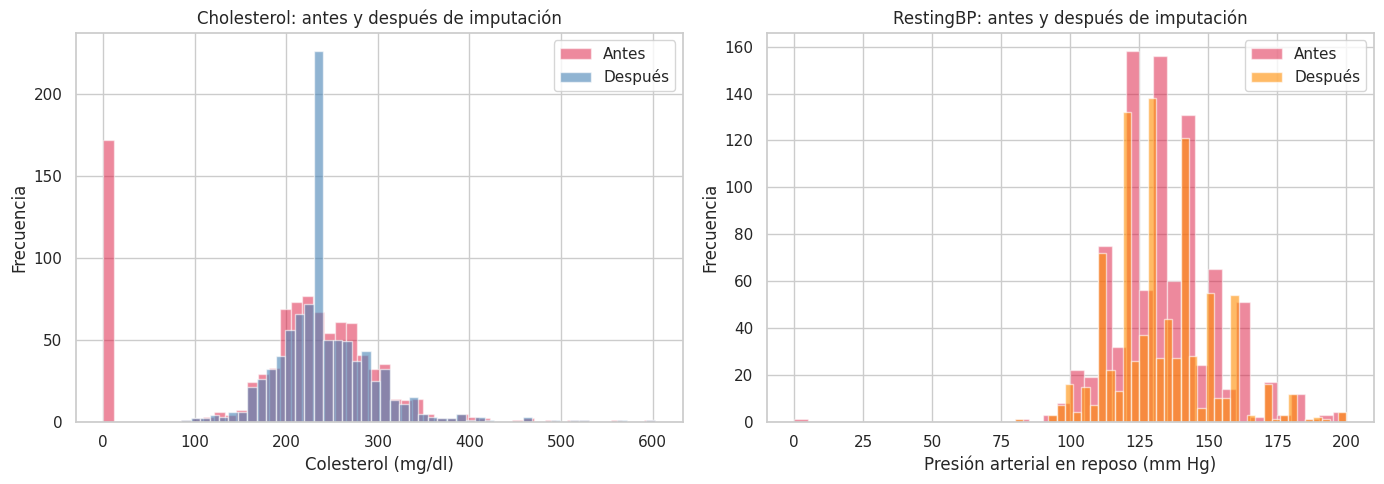


RESUMEN DEL DATASET LIMPIO
Registros originales : 918
Registros finales    : 918  (sin eliminaciones)
Features             : 11  predictoras + 1 target
Valores nulos        : 0


,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
RestingBP,918.0,132.538126,17.990127,80.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,243.204793,53.401297,85.0,214.0,237.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.0,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.0,1.0,1.0,1.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colesterol antes vs después
ax = axes[0]
ax.hist(df['Cholesterol'],       bins=50, alpha=0.5, color='crimson',   label='Antes', edgecolor='white')
ax.hist(df_clean['Cholesterol'], bins=50, alpha=0.6, color='steelblue', label='Después', edgecolor='white')
ax.set_title('Cholesterol: antes y después de imputación', fontsize=12)
ax.set_xlabel('Colesterol (mg/dl)')
ax.set_ylabel('Frecuencia')
ax.legend()

# RestingBP antes vs después
ax = axes[1]
ax.hist(df['RestingBP'],       bins=40, alpha=0.5, color='crimson',   label='Antes', edgecolor='white')
ax.hist(df_clean['RestingBP'], bins=40, alpha=0.6, color='darkorange', label='Después', edgecolor='white')
ax.set_title('RestingBP: antes y después de imputación', fontsize=12)
ax.set_xlabel('Presión arterial en reposo (mm Hg)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

# Resumen final
print('\n' + '=' * 55)
print('RESUMEN DEL DATASET LIMPIO')
print('=' * 55)
print(f'Registros originales : {df.shape[0]}')
print(f'Registros finales    : {df_clean.shape[0]}  (sin eliminaciones)')
print(f'Features             : {df_clean.shape[1] - 1}  predictoras + 1 target')
print(f'Valores nulos        : {df_clean.isnull().sum().sum()}')
df_clean.describe().T

##Análisis exploratiorio de los datos:

In [9]:
# Trabajamos sobre el dataset ya imputado
num_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
cat_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

pd.set_option('display.precision', 2)
print('Numéricas  :', num_features)
print('Categóricas:', cat_features)
print()
df_clean[num_features].describe().T

Numéricas  : ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Categóricas: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']



,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.51,9.43,28.0,47.0,54.0,60.0,77.0
RestingBP,918.0,132.54,17.99,80.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,243.20,53.40,85.0,214.0,237.0,267.0,603.0
MaxHR,918.0,136.81,25.46,60.0,120.0,138.0,156.0,202.0
Oldpeak,918.0,0.89,1.07,-2.6,0.0,0.6,1.5,6.2


Balance de la clase objetivo

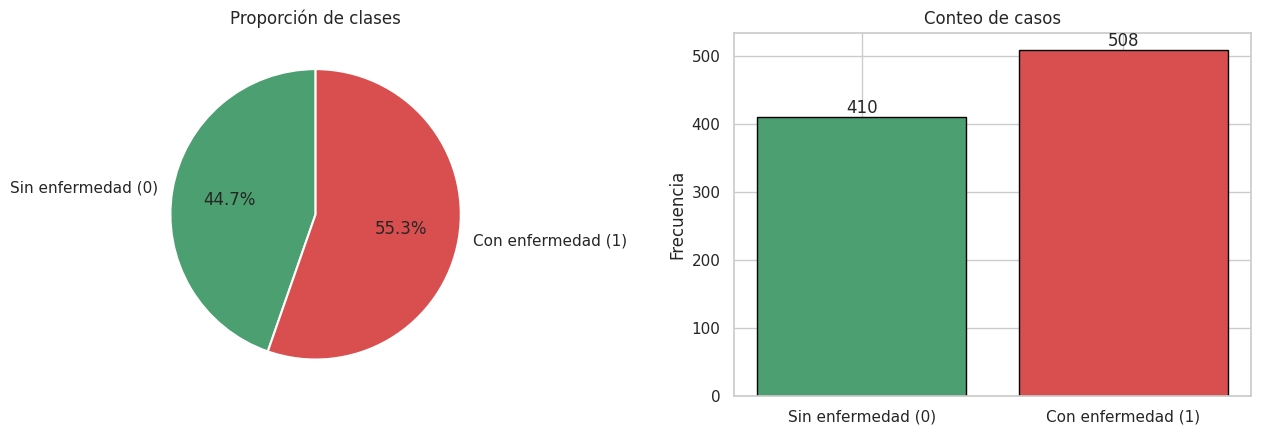

Balance: 508 positivos / 410 negativos (55.3% / 44.7%)


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

counts = df_clean['HeartDisease'].value_counts().sort_index()
labels = ['Sin enfermedad (0)', 'Con enfermedad (1)']
colors = ['#4C9F70', '#D94F4F']

ax[0].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90,
          colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax[0].set_title('Proporción de clases')

bars = ax[1].bar(labels, counts, color=colors, edgecolor='black')
ax[1].bar_label(bars)
ax[1].set_title('Conteo de casos')
ax[1].set_ylabel('Frecuencia')

plt.tight_layout(); plt.show()

print(f'Balance: {counts[1]} positivos / {counts[0]} negativos '
      f'({counts[1]/len(df_clean)*100:.1f}% / {counts[0]/len(df_clean)*100:.1f}%)')

- Con esto se puede afirmar que el target esta balanceado, ya que sus posibles valores representan cada uno la mitad de los datos.

Distribución de las clases númericas

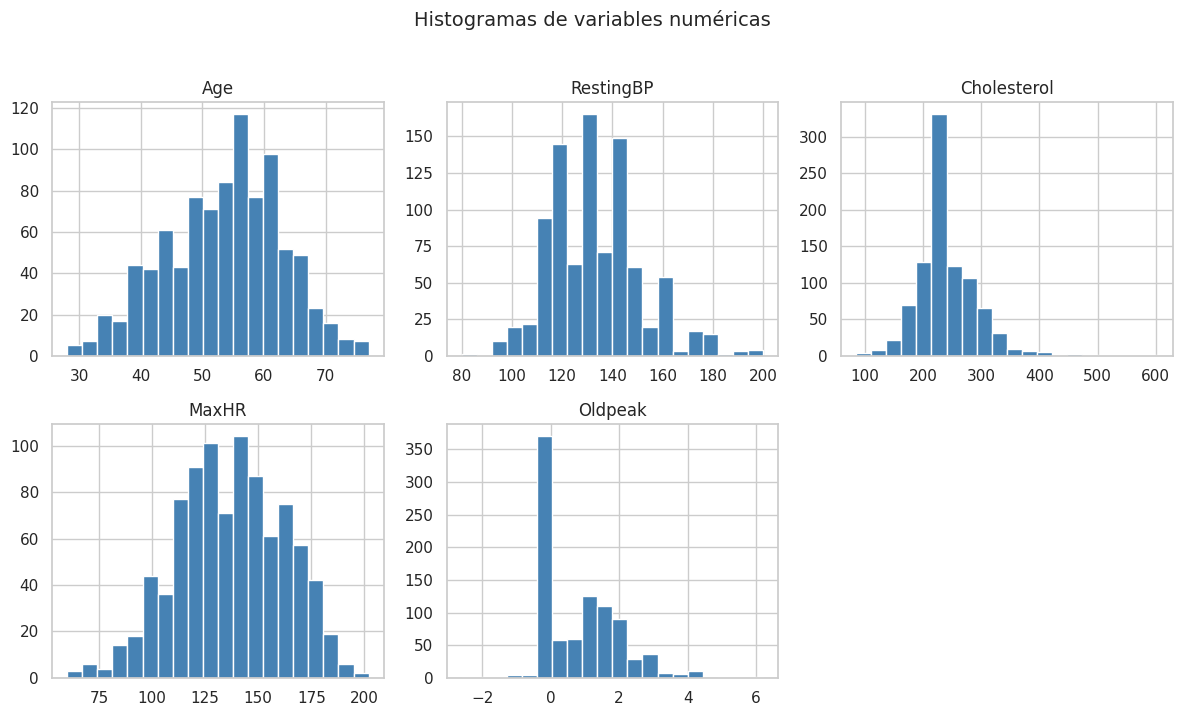

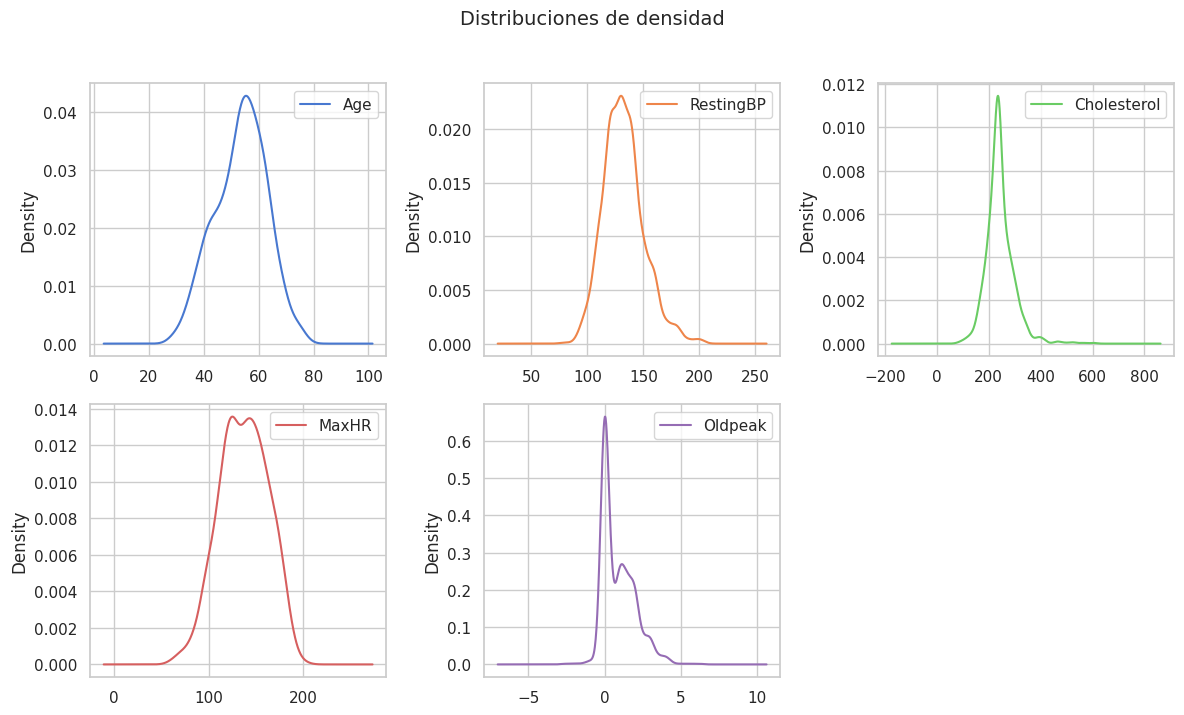

Asimetría (skewness) de cada variable:
Age           -0.20
RestingBP      0.61
Cholesterol    1.45
MaxHR         -0.14
Oldpeak        1.02


In [11]:
# Histogramas
df_clean[num_features].hist(bins=20, figsize=(12, 7), color='steelblue',
                            edgecolor='white', layout=(2, 3))
plt.suptitle('Histogramas de variables numéricas', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

# Densidad
df_clean[num_features].plot(kind='density', subplots=True, layout=(2, 3),
                            sharex=False, figsize=(12, 7))
plt.suptitle('Distribuciones de densidad', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

print('Asimetría (skewness) de cada variable:')
print(df_clean[num_features].skew().round(3).to_string())

Boxplots por feature y target

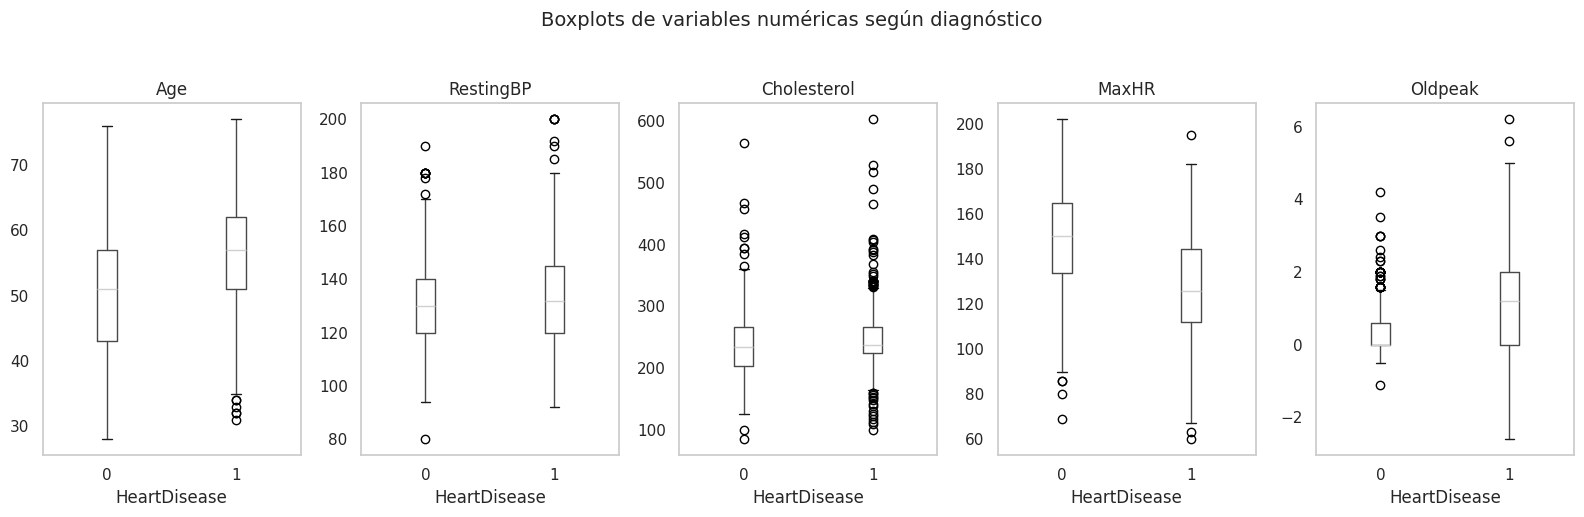

In [12]:
fig, axes = plt.subplots(1, len(num_features), figsize=(16, 5))
for ax, col in zip(axes, num_features):
    df_clean.boxplot(column=col, by='HeartDisease', ax=ax, grid=False)
    ax.set_title(col); ax.set_xlabel('HeartDisease')
plt.suptitle('Boxplots de variables numéricas según diagnóstico', y=1.03, fontsize=14)
plt.tight_layout(); plt.show()

Comparación de variables categóricas con target

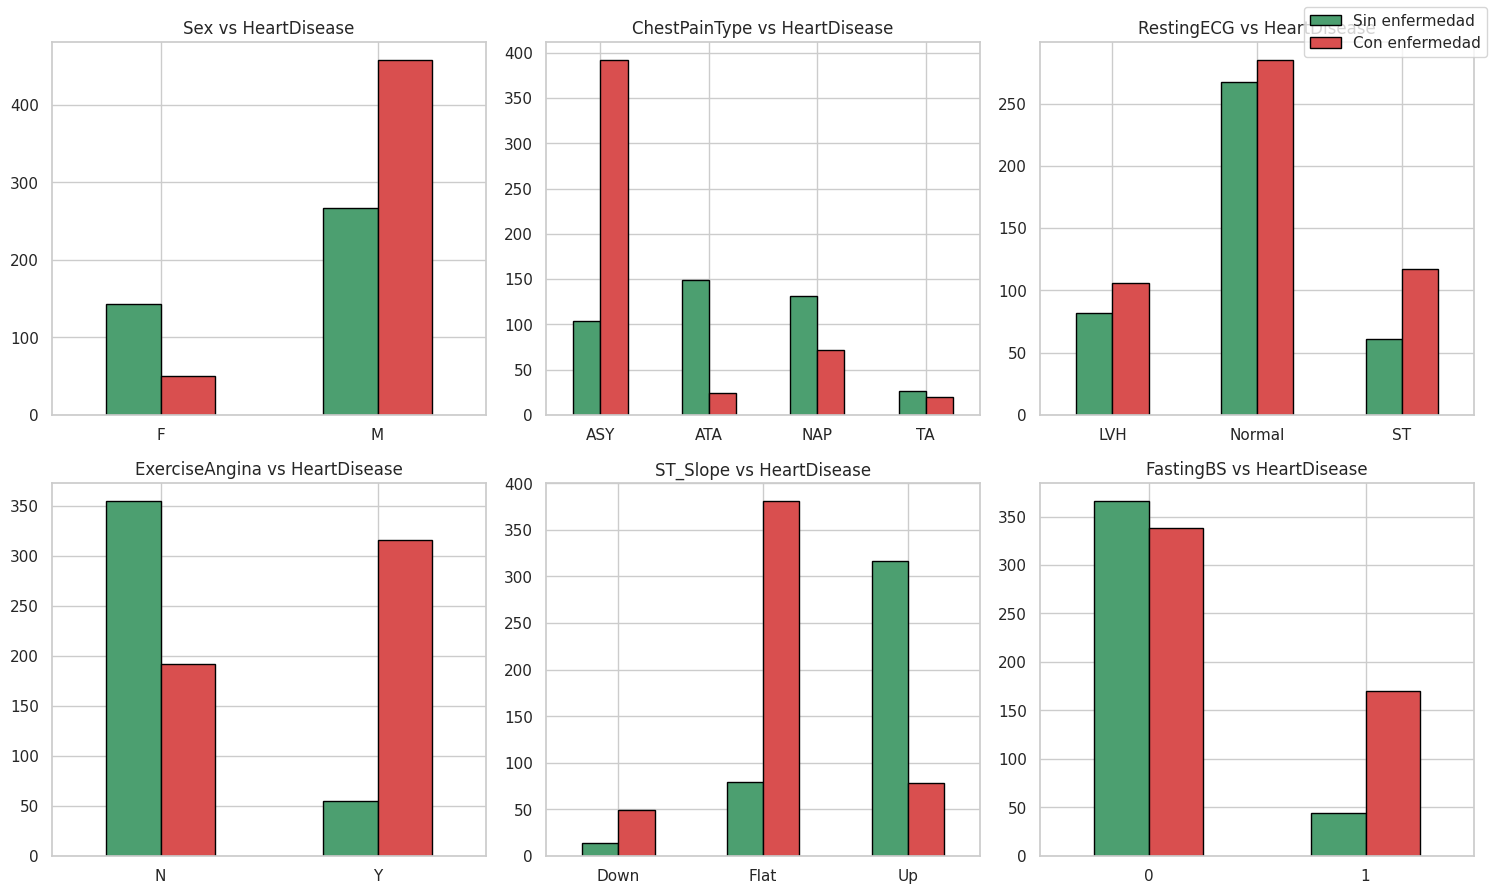

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flat, cat_features):
    ct = pd.crosstab(df_clean[col], df_clean['HeartDisease'])
    ct.plot(kind='bar', stacked=False, ax=ax, color=colors,
            edgecolor='black', legend=False)
    ax.set_title(f'{col} vs HeartDisease'); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
fig.legend(['Sin enfermedad', 'Con enfermedad'], loc='upper right')
plt.tight_layout(); plt.show()


In [14]:
# Tasa de enfermedad por categoría
print('TASA DE ENFERMEDAD POR CATEGORÍA:')
for col in cat_features:
    rate = df_clean.groupby(col)['HeartDisease'].mean().sort_values(ascending=False)
    print(f'\n{col}:')
    for k, v in rate.items():
        print(f'   {str(k):8s} → {v*100:5.1f}%')

TASA DE ENFERMEDAD POR CATEGORÍA:

Sex:
   M        →  63.2%
   F        →  25.9%

ChestPainType:
   ASY      →  79.0%
   TA       →  43.5%
   NAP      →  35.5%
   ATA      →  13.9%

RestingECG:
   ST       →  65.7%
   LVH      →  56.4%
   Normal   →  51.6%

ExerciseAngina:
   Y        →  85.2%
   N        →  35.1%

ST_Slope:
   Flat     →  82.8%
   Down     →  77.8%
   Up       →  19.7%

FastingBS:
   1        →  79.4%
   0        →  48.0%


Correlaciones entre feartures y target

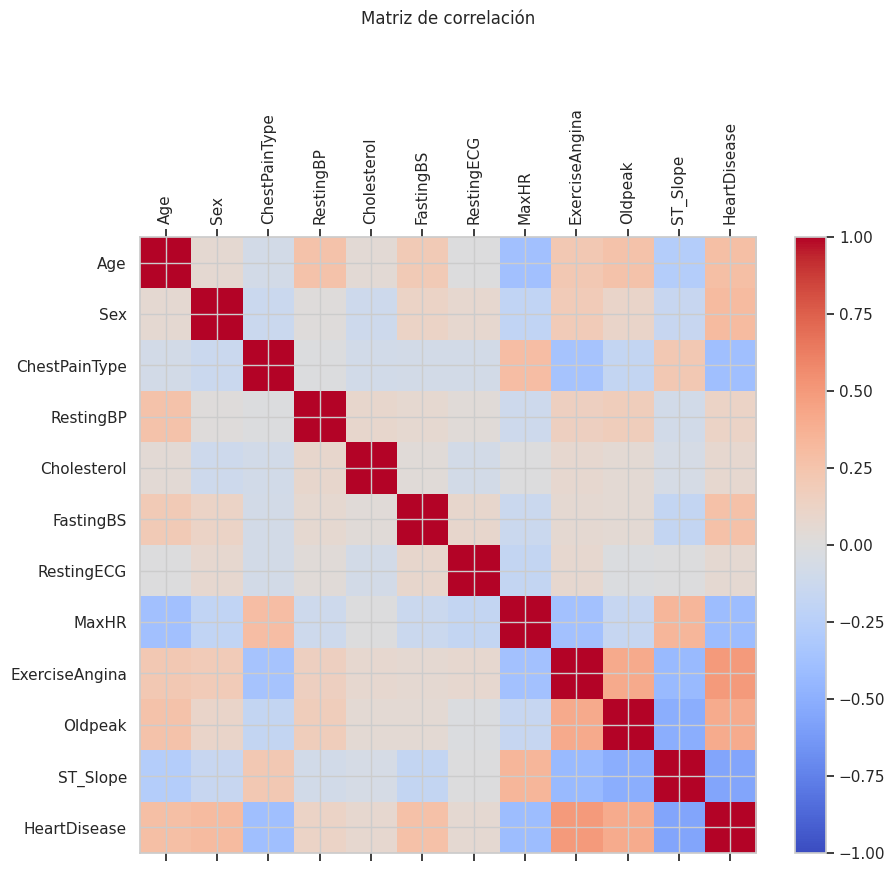

In [15]:
from sklearn.preprocessing import LabelEncoder

# Copia codificada para incluir categóricas en la correlación
df_enc = df_clean.copy()
for col in cat_features:
    if df_enc[col].dtype != 'int64':
        df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

corr = df_enc.corr()

# Plot estilo matshow
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
cax = ax.matshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(cax)
ticks = np.arange(len(corr.columns))
ax.set_xticks(ticks); ax.set_yticks(ticks)
ax.set_xticklabels(corr.columns, rotation=90); ax.set_yticklabels(corr.columns)
plt.title('Matriz de correlación', pad=60); plt.show()


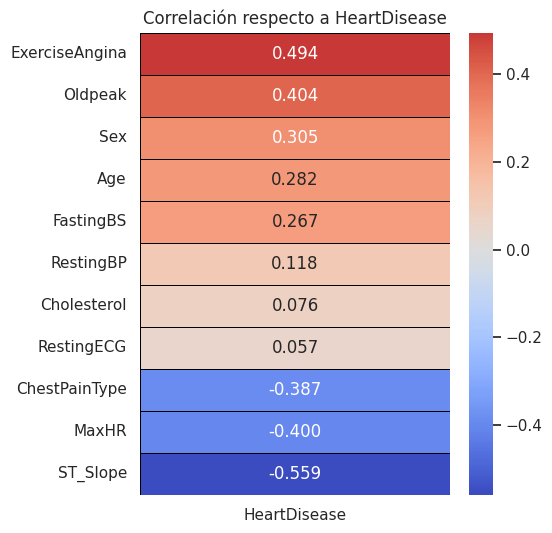

In [16]:
# Correlación SOLO respecto al target (ordenada)
corr_target = corr['HeartDisease'].drop('HeartDisease').sort_values(ascending=False)
plt.figure(figsize=(5, 6))
sns.heatmap(corr_target.to_frame(), annot=True, cmap='coolwarm',
            center=0, fmt='.3f', linewidths=0.5, linecolor='black')
plt.title('Correlación respecto a HeartDisease'); plt.show()

Pruebas estadísticas para analizar la relación entre los features y el target

ANOVA (numéricas):
              F_score   p_value
Oldpeak       178.62  0.00e+00
MaxHR         174.91  0.00e+00
Age            79.16  0.00e+00
RestingBP      12.89  3.00e-04
Cholesterol     5.34  2.11e-02 

Chi² (categóricas):
                 Chi2_score  p_value
ChestPainType       160.74     0.00
ExerciseAngina      133.64     0.00
ST_Slope             77.49     0.00
FastingBS            50.30     0.00
Sex                  18.01     0.00
RestingECG            1.22     0.27


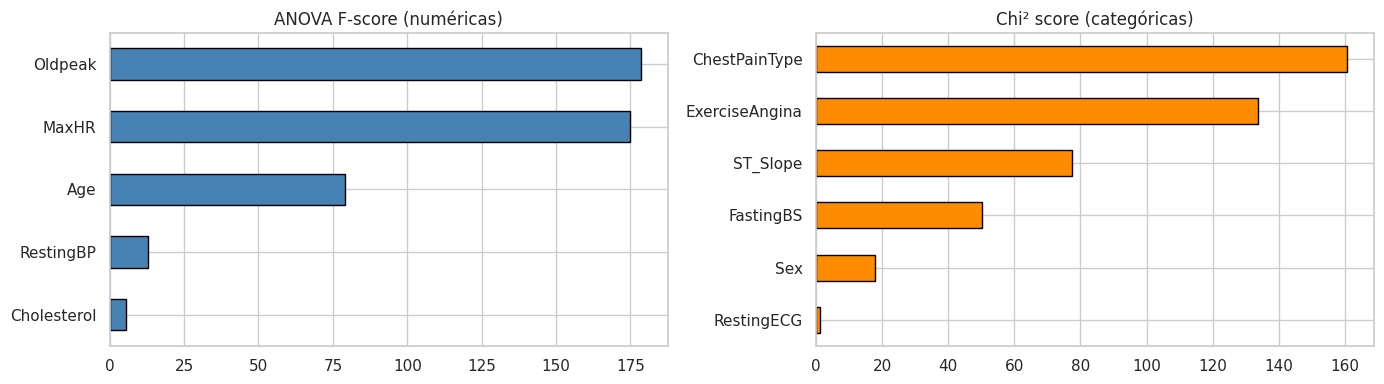

In [17]:
from sklearn.feature_selection import f_classif, chi2

# ANOVA para numéricas
F, pF = f_classif(df_clean[num_features], df_clean['HeartDisease'])
anova = pd.DataFrame({'F_score': F, 'p_value': pF},
                     index=num_features).sort_values('F_score', ascending=False)

# Chi² para categóricas (requiere valores no negativos → usamos codificadas)
ch, pc = chi2(df_enc[cat_features], df_clean['HeartDisease'])
chi = pd.DataFrame({'Chi2_score': ch, 'p_value': pc},
                   index=cat_features).sort_values('Chi2_score', ascending=False)

print('ANOVA (numéricas):\n', anova.round(4), '\n')
print('Chi² (categóricas):\n', chi.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
anova['F_score'].plot(kind='barh', ax=ax[0], color='steelblue', edgecolor='black')
ax[0].set_title('ANOVA F-score (numéricas)'); ax[0].invert_yaxis()
chi['Chi2_score'].plot(kind='barh', ax=ax[1], color='darkorange', edgecolor='black')
ax[1].set_title('Chi² score (categóricas)'); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

Hallazgos del análisis exploratorio

Variables más predictivas (consistentes entre correlación, ANOVA y Chi²):
- ST_Slope presenta en sus clases una división muy marcada de que clases son propensas a presentar enfermedad y las que no lo son. Por un lado tenemos a Flat con un 82.8% de casos de enfermedad y por otro
 tenemos Up con un 19.7% de casos de enfermos. Además presenta una alta correlación inversa con target.
- ChestPainType de acuerdo a la prueba chi2 se puede afirmar que la variable presenta una alta relación con el target. Otro factor que nos indica una relación con target es la diferencia entre las clases del
  feature que muestra que unas de sus clases tienen a presentar mayor cantidad de enfermos que otras.
- ExerciseAngina presenta una alta relación con el target de acuerdo a la prueba chi cuadrado. Además, presenta una alta correlación con target a  comparación de los demás features y sus clases muestran una
indicio de presentar más enfermos en un mientras que la otra presenta más paciente sanos.
- Oldpeak presenta una diferencia en los valores medios entre enfermos y no enfermos de acuerdo a la prueba ANOVA, lo que indica que es un buen feature para discriminar entre enfermos y sanos ya que para un caso
u otro una cantidad de valores va a estar más asociado a los enfermos y otro a los sanos.
- MaxHR al igual quue Oldpeak presenta un alto valor en la prueba ANOVA lo que indica que posiblemente sea un buen discriminador.
- Age aunque no presente un alto valor en ANOVA y en su correlación, guiandonos del boxplot podemos decir que los enfermos usualmente tienden a estar enfermos mientras los sanos usualmente tienen una edad menor.

Variables débiles: RestingECG (Chi²=1.22, p=0.27 → no significativa), Cholesterol (r=0.076) y RestingBP (r=0.118)

##Feaute Engineering

## Feature Engineering: Variables Derivadas

A partir de las 11 variables originales del dataset se construyeron 5 nuevas
variables derivadas, con respaldo en literatura académica indexada. Cada una
captura una relación clínica que las variables crudas no expresan directamente.

---

### Feature 1 — HR_Reserve (Índice Cronotrópico)

**Fórmula:** `HR_Reserve = MaxHR / (220 − Age)`

**Variables base:** MaxHR, Age

**Descripción:**
Representa la fracción de la frecuencia cardíaca máxima teórica (predicha por
edad) que el paciente logró alcanzar durante la prueba de esfuerzo. La fórmula
"220 − Age" es el estándar clínico para estimar la frecuencia cardíaca máxima
esperada según la edad del paciente.

**Rango esperado:** 0.40 – 1.10 (valores típicos entre 0.60 y 1.05)

**Interpretación clínica:**
- HR_Reserve ≥ 0.85  → respuesta cronotrópica normal, menor riesgo
- HR_Reserve < 0.85  → insuficiencia cronotrópica, asociada a mayor riesgo
                        cardiovascular independientemente de otros factores

Un corazón enfermo tiene dificultad para incrementar su frecuencia durante
el ejercicio, por lo que pacientes cardíacos tienden a presentar valores más
bajos de HR_Reserve.

---

### Feature 2 — Exercise_Stress_Score (Puntuación de Estrés en Ejercicio)

**Fórmula:** `Exercise_Stress_Score = Oldpeak × ExerciseAngina_bin`
             donde ExerciseAngina_bin = 1 si ExerciseAngina = 'Y', 0 si = 'N'

**Variables base:** Oldpeak, ExerciseAngina

**Descripción:**
Combina la magnitud de la depresión del segmento ST (Oldpeak) con la presencia
de angina inducida por ejercicio en un único indicador. Captura la coexistencia
de ambas condiciones, que en la literatura clínica se asocia de forma sinérgica
a mayor probabilidad de enfermedad cardíaca.

**Rango esperado:** 0.0 – 6.2

**Interpretación clínica:**
- Score = 0   → sin angina de esfuerzo (independientemente del Oldpeak)
- Score > 0   → angina presente Y depresión del ST, combinación de alto riesgo
- Score alto  → mayor depresión del ST con angina simultánea, riesgo elevado

Cuando no hay angina de esfuerzo, el score colapsa a 0 aunque exista alguna
depresión del ST, diferenciando así los patrones de riesgo combinado.

---

### Feature 3 — Cumulative_Risk_Score (Puntuación de Riesgo Acumulado)

**Fórmula:**
  high_BP_bin   = 1 si RestingBP > 140 mm Hg,  si no 0
  high_chol_bin = 1 si Cholesterol > 240 mg/dl, si no 0
  `Cumulative_Risk_Score = FastingBS + high_BP_bin + high_chol_bin`

**Variables base:** FastingBS, RestingBP, Cholesterol

**Descripción:**
Suma tres indicadores binarios de los factores de riesgo metabólico clásicos
reconocidos por la clínica cardiovascular: diabetes (aproximada por glucemia en
ayunas elevada), hipertensión y hipercolesterolemia. Representa la carga de
riesgo metabólico acumulada de cada paciente.

**Rango:** 0 – 3  (entero)
- 0 → ningún factor de riesgo metabólico presente
- 1 → un factor presente
- 2 → dos factores presentes
- 3 → los tres factores presentes simultáneamente (máximo riesgo metabólico)

**Umbrales clínicos utilizados:**
- RestingBP > 140 mm Hg  → criterio estándar de hipertensión arterial (OMS)
- Cholesterol > 240 mg/dl → criterio de hipercolesterolemia (AHA/ACC)
- FastingBS = 1           → glucemia en ayunas > 120 mg/dl (ya binaria en el
                            dataset, proxy de diabetes o prediabetes)

---

### Feature 4 — Age_Group (Grupo Etario)

**Fórmula:**
  `Age_Group = 0  si Age < 45`        (riesgo bajo)
  `Age_Group = 1  si 45 ≤ Age < 55`   (riesgo moderado)
  `Age_Group = 2  si 55 ≤ Age < 65`   (riesgo alto)
  `Age_Group = 3  si Age ≥ 65`        (riesgo muy alto)

**Variables base:** Age

**Descripción:**
Discretiza la edad continua en cuatro grupos de riesgo clínicamente reconocidos.
Captura la relación no lineal entre edad y enfermedad cardíaca: el riesgo no
aumenta de forma uniforme con cada año, sino que se acelera notablemente a
partir de los 50–55 años.

**Rango:** 0, 1, 2, 3  (categórica ordinal)

**Distribución en el dataset (orientativa):**
- Grupo 0 (< 45 años)    →  menor prevalencia de enfermedad
- Grupo 1 (45–54 años)   →  riesgo moderado
- Grupo 2 (55–64 años)   →  riesgo alto, mayor concentración de casos
- Grupo 3 (≥ 65 años)    →  riesgo muy alto

La mediana de edad en pacientes con enfermedad es ~55 años vs ~47 años en
pacientes sanos dentro de este dataset, lo que justifica los puntos de corte.

---

### Feature 5 — Cholesterol_Age_Ratio (Ratio Colesterol-Edad)

**Fórmula:** `Cholesterol_Age_Ratio = Cholesterol / Age`

**Variables base:** Cholesterol, Age

**Descripción:**
Normaliza el nivel de colesterol sérico respecto a la edad del paciente.
Un colesterol de 280 mg/dl en un paciente de 40 años implica un tiempo de
exposición vascular mucho mayor que el mismo valor en uno de 70 años, lo que
se traduce en mayor daño arterial acumulado. Este ratio captura esa diferencia
que la variable de colesterol crudo no puede expresar sola.

**Rango esperado en el dataset:** ~3.5 – 10.0

**Interpretación:**
- Ratio alto  → colesterol elevado en paciente relativamente joven
               (mayor acumulación de riesgo por tiempo de exposición)
- Ratio bajo  → colesterol moderado o paciente de mayor edad
               (menor exposición relativa al factor de riesgo)

La unidad resultante es mg/dl por año de vida, interpretable como
"carga de colesterol por año de exposición vascular".

---

### Resumen de Features Derivados

| Feature                | Fórmula resumida                         | Rango         |
|------------------------|------------------------------------------|---------------|
| HR_Reserve             | MaxHR / (220 − Age)                      | 0.40 – 1.10   |
| Exercise_Stress_Score  | Oldpeak × ExerciseAngina_bin             | 0.0 – 6.2     |
| Cumulative_Risk_Score  | FastingBS + high_BP_bin + high_chol_bin  | 0 – 3         |
| Age_Group              | Discretización de Age en 4 rangos        | 0, 1, 2, 3    |
| Cholesterol_Age_Ratio  | Cholesterol / Age                        | 3.5 – 10.0    |

In [18]:
# Partimos del dataset ya imputado (df_clean del preprocesamiento)
df_fe = df_clean.copy()


In [19]:
# Partimos del dataset ya imputado (df_clean del preprocesamiento)
df_fe = df_clean.copy()

# ---------------------------------------------------------------
# FEATURE 1 — HR_Reserve (Índice Cronotrópico)
# Fórmula: MaxHR / (220 - Age)
# Fracción de la FC máxima teórica alcanzada en la prueba de esfuerzo
# ---------------------------------------------------------------
df_fe['HR_Reserve'] = df_fe['MaxHR'] / (220 - df_fe['Age'])

# ---------------------------------------------------------------
# FEATURE 2 — Exercise_Stress_Score
# Fórmula: Oldpeak × ExerciseAngina_bin
# Captura la coexistencia de depresión del ST y angina de esfuerzo.
# Se aplica clip(lower=0) sobre Oldpeak porque el feature representa
# depresión del ST (valores positivos). Los 3 registros con
# ExerciseAngina='Y' y Oldpeak negativo (elevación ST) producirían
# un score negativo que contradice la interpretación clínica.
# ---------------------------------------------------------------
exang_bin = (df_fe['ExerciseAngina'] == 'Y').astype(int)
df_fe['Exercise_Stress_Score'] = df_fe['Oldpeak'].clip(lower=0) * exang_bin

# ---------------------------------------------------------------
# FEATURE 3 — Cumulative_Risk_Score
# Fórmula: FastingBS + high_BP_bin + high_chol_bin
# Umbrales: RestingBP > 140 mmHg (hipertensión, OMS)
#           Cholesterol > 240 mg/dl (hipercolesterolemia, AHA/ACC)
# ---------------------------------------------------------------
high_bp_bin   = (df_fe['RestingBP']   > 140).astype(int)
high_chol_bin = (df_fe['Cholesterol'] > 240).astype(int)
df_fe['Cumulative_Risk_Score'] = df_fe['FastingBS'] + high_bp_bin + high_chol_bin

# ---------------------------------------------------------------
# FEATURE 4 — Age_Group (Grupo Etario)
# Discretización de Age en 4 grupos de riesgo cardiovascular
# ---------------------------------------------------------------
df_fe['Age_Group'] = pd.cut(
    df_fe['Age'],
    bins   = [0, 44, 54, 64, 120],
    labels = [0, 1, 2, 3]
).astype(int)

# ---------------------------------------------------------------
# FEATURE 5 — Cholesterol_Age_Ratio
# Fórmula: Cholesterol / Age
# Normaliza el colesterol por el tiempo de exposición vascular
# ---------------------------------------------------------------
df_fe['Cholesterol_Age_Ratio'] = df_fe['Cholesterol'] / df_fe['Age']

print('Features derivados creados correctamente.')
print(f'Shape original : {df_clean.shape}')
print(f'Shape con FE   : {df_fe.shape}')
print(f'Nuevas columnas: {[c for c in df_fe.columns if c not in df_clean.columns]}')

Features derivados creados correctamente.
Shape original : (918, 12)
Shape con FE   : (918, 17)
Nuevas columnas: ['HR_Reserve', 'Exercise_Stress_Score', 'Cumulative_Risk_Score', 'Age_Group', 'Cholesterol_Age_Ratio']


Valores y rangos de las nuevas features

In [20]:
new_features = [
    'HR_Reserve',
    'Exercise_Stress_Score',
    'Cumulative_Risk_Score',
    'Age_Group',
    'Cholesterol_Age_Ratio'
]

print('=' * 60)
print('ESTADÍSTICAS DE FEATURES DERIVADOS')
print('=' * 60)
df_fe[new_features].describe().T.round(3)

ESTADÍSTICAS DE FEATURES DERIVADOS


,count,mean,std,min,25%,50%,75%,max
HR_Reserve,918.0,0.82,0.14,0.35,0.72,0.82,0.93,1.18
Exercise_Stress_Score,918.0,0.58,0.96,0.00,0.00,0.00,1.00,5.60
Cumulative_Risk_Score,918.0,0.86,0.79,0.00,0.00,1.00,1.00,3.00
Age_Group,918.0,1.41,0.92,0.00,1.00,1.00,2.00,3.00
Cholesterol_Age_Ratio,918.0,4.69,1.37,1.49,3.82,4.43,5.31,16.53


Verificación de valores nulos y distribución de categóricas

In [21]:
print('Valores nulos en features derivados:')
print(df_fe[new_features].isnull().sum())

print()
print('Cumulative_Risk_Score — distribución:')
print(df_fe['Cumulative_Risk_Score'].value_counts().sort_index()
      .rename({0:'Sin factores', 1:'1 factor', 2:'2 factores', 3:'3 factores'}))

print()
print('Age_Group — distribución:')
labels_ag = {0:'< 45 años', 1:'45–54 años', 2:'55–64 años', 3:'≥ 65 años'}
print(df_fe['Age_Group'].value_counts().sort_index().rename(labels_ag))

print()
print('Exercise_Stress_Score:')
print(f'  Score = 0 (sin angina o sin depresión ST) : '
      f'{(df_fe["Exercise_Stress_Score"]==0).sum()} registros')
print(f'  Score > 0 (angina + depresión ST)         : '
      f'{(df_fe["Exercise_Stress_Score"]>0).sum()} registros')

Valores nulos en features derivados:
HR_Reserve               0
Exercise_Stress_Score    0
Cumulative_Risk_Score    0
Age_Group                0
Cholesterol_Age_Ratio    0
dtype: int64

Cumulative_Risk_Score — distribución:
Cumulative_Risk_Score
Sin factores    333
1 factor        406
2 factores      154
3 factores       25
Name: count, dtype: int64

Age_Group — distribución:
Age_Group
< 45 años     178
45–54 años    293
55–64 años    344
≥ 65 años     103
Name: count, dtype: int64

Exercise_Stress_Score:
  Score = 0 (sin angina o sin depresión ST) : 613 registros
  Score > 0 (angina + depresión ST)         : 305 registros


Visualización de los features derivados

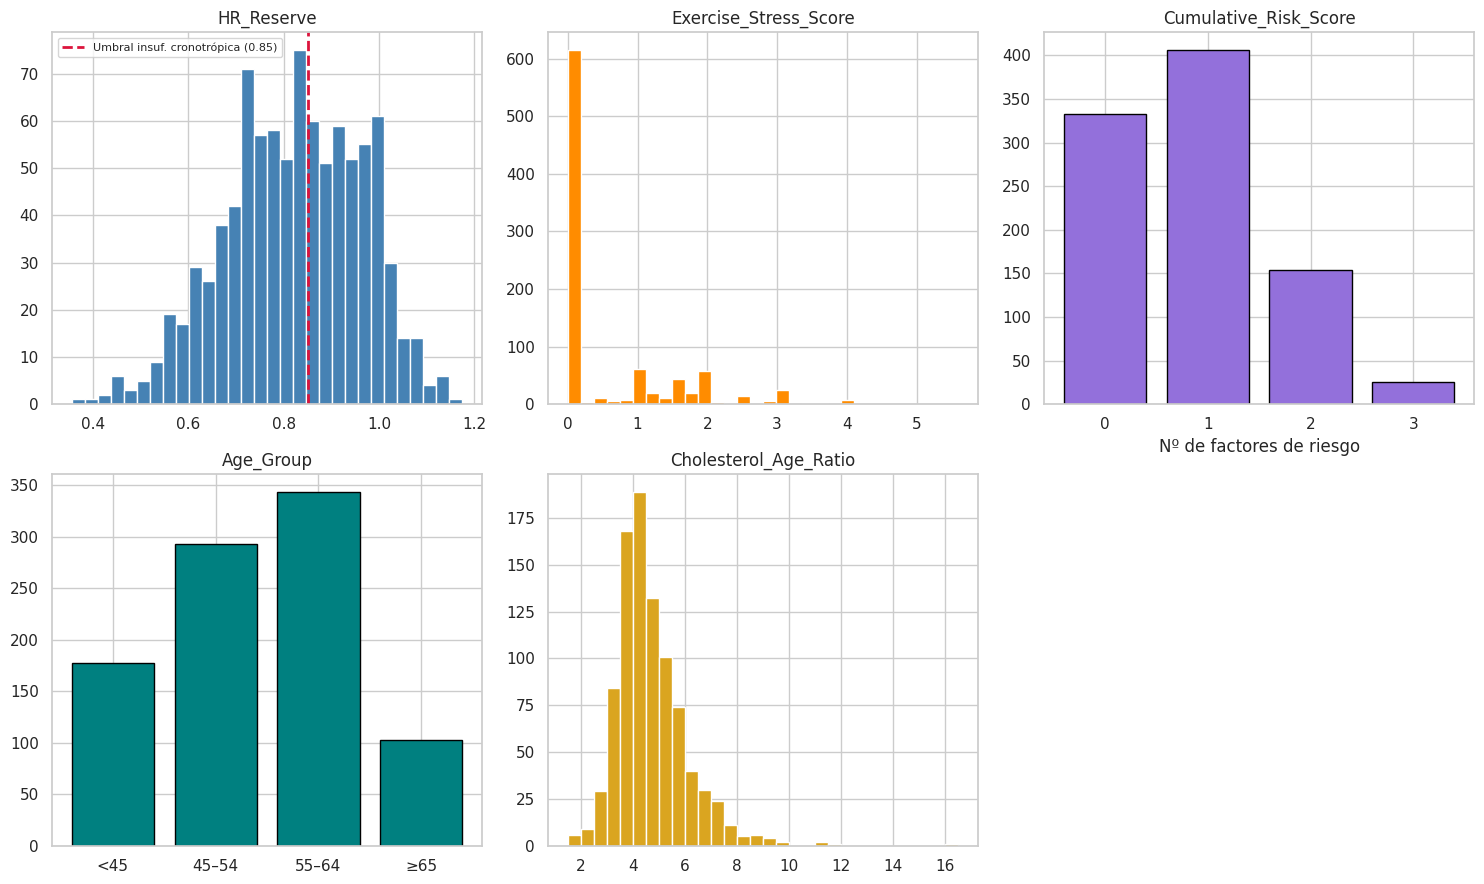

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
colors = ['#4C9F70', '#D94F4F']

# HR_Reserve
axes[0,0].hist(df_fe['HR_Reserve'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].axvline(0.85, color='crimson', linestyle='--', linewidth=2,
                  label='Umbral insuf. cronotrópica (0.85)')
axes[0,0].set_title('HR_Reserve'); axes[0,0].legend(fontsize=8)

# Exercise_Stress_Score
axes[0,1].hist(df_fe['Exercise_Stress_Score'], bins=30,
               color='darkorange', edgecolor='white')
axes[0,1].set_title('Exercise_Stress_Score')

# Cumulative_Risk_Score
crs_counts = df_fe['Cumulative_Risk_Score'].value_counts().sort_index()
axes[0,2].bar(crs_counts.index, crs_counts.values,
              color='mediumpurple', edgecolor='black')
axes[0,2].set_title('Cumulative_Risk_Score')
axes[0,2].set_xticks([0,1,2,3])
axes[0,2].set_xlabel('Nº de factores de riesgo')

# Age_Group
ag_counts = df_fe['Age_Group'].value_counts().sort_index()
axes[1,0].bar(ag_counts.index, ag_counts.values,
              color='teal', edgecolor='black')
axes[1,0].set_title('Age_Group')
axes[1,0].set_xticks([0,1,2,3])
axes[1,0].set_xticklabels(['<45','45–54','55–64','≥65'])

# Cholesterol_Age_Ratio
axes[1,1].hist(df_fe['Cholesterol_Age_Ratio'], bins=30,
               color='goldenrod', edgecolor='white')
axes[1,1].set_title('Cholesterol_Age_Ratio')


num_derived = ['HR_Reserve', 'Exercise_Stress_Score', 'Cholesterol_Age_Ratio']
ax = axes[1,2]
ax.axis('off')  # ocultamos el sexto espacio

plt.tight_layout()
plt.show()

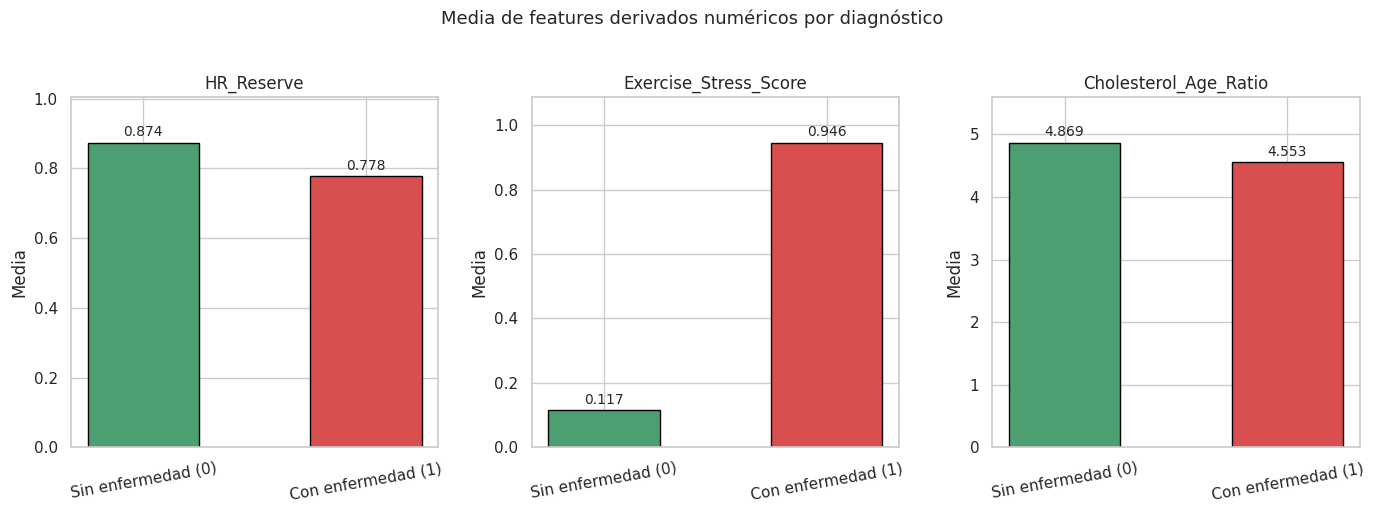

Valores exactos:
HeartDisease           Sin enfermedad  Con enfermedad
HR_Reserve                       0.87            0.78
Exercise_Stress_Score            0.12            0.95
Cholesterol_Age_Ratio            4.87            4.55


In [23]:
num_derived = ['HR_Reserve', 'Exercise_Stress_Score', 'Cholesterol_Age_Ratio']
labels_hd   = ['Sin enfermedad (0)', 'Con enfermedad (1)']

fig2, axes2 = plt.subplots(1, 3, figsize=(14, 5))

for ax, feat in zip(axes2, num_derived):
    means = df_fe.groupby('HeartDisease')[feat].mean()
    bars  = ax.bar(labels_hd, means.values, color=colors,
                   edgecolor='black', width=0.5)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (means.max() * 0.01),
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(feat, fontsize=12)
    ax.set_ylabel('Media')
    ax.tick_params(axis='x', rotation=10)
    ax.set_ylim(0, means.max() * 1.15)

plt.suptitle('Media de features derivados numéricos por diagnóstico',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Valores exactos:')
print(df_fe.groupby('HeartDisease')[num_derived].mean().round(4)
      .rename(index={0:'Sin enfermedad', 1:'Con enfermedad'}).T.to_string())

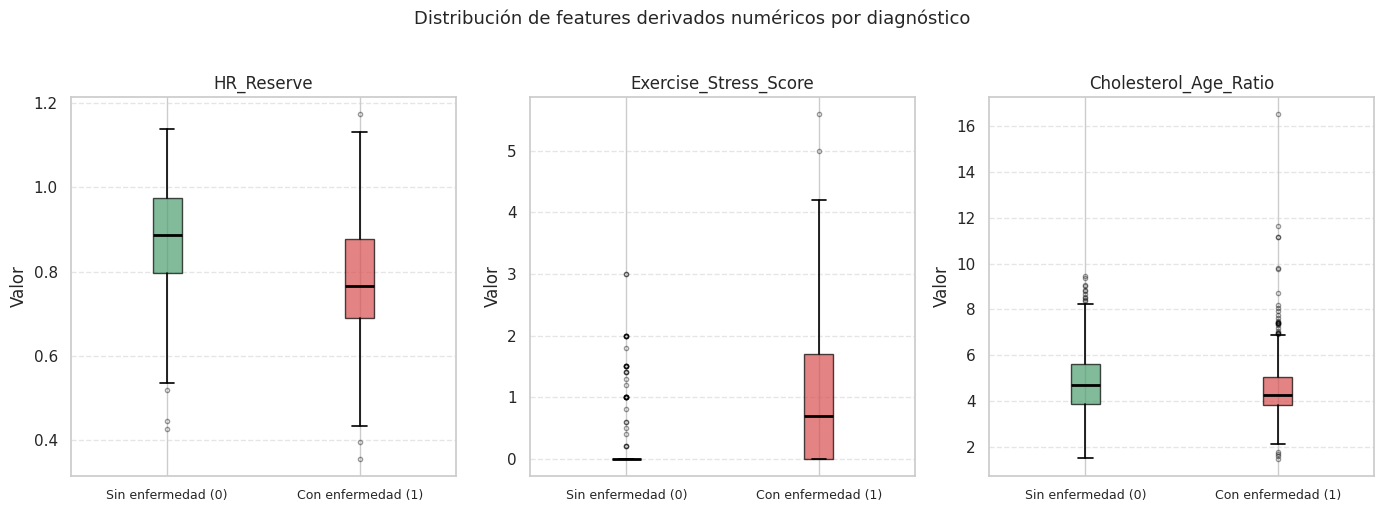

In [24]:
num_derived_cont = ['HR_Reserve', 'Exercise_Stress_Score', 'Cholesterol_Age_Ratio']
colors = ['#4C9F70', '#D94F4F']
labels_hd = ['Sin enfermedad (0)', 'Con enfermedad (1)']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, feat in zip(axes, num_derived_cont):

    grupos = [df_fe.loc[df_fe['HeartDisease'] == 0, feat].values,
              df_fe.loc[df_fe['HeartDisease'] == 1, feat].values]

    bp = ax.boxplot(grupos,
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=3,
                                   alpha=0.4, linestyle='none'))

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(feat, fontsize=12)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels_hd, fontsize=9)
    ax.set_ylabel('Valor')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Distribución de features derivados numéricos por diagnóstico',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Correlación de features derivados con el target

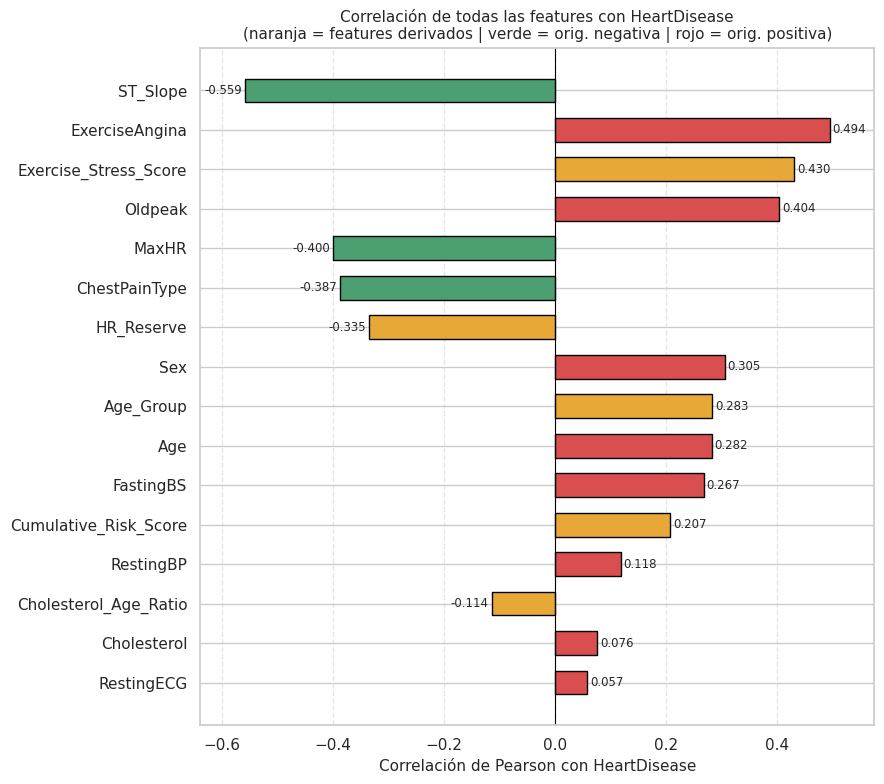

In [25]:
from sklearn.preprocessing import LabelEncoder

# Codificar categóricas para calcular correlación
df_corr = df_fe.copy()
for col in ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# Calcular correlación con target ordenada por valor absoluto
corr_target = (df_corr.corr()['HeartDisease']
               .drop('HeartDisease')
               .sort_values(key=abs, ascending=True))

# Colorear: naranja = derivados | rojo = original positiva | verde = original negativa
derived_feats = ['HR_Reserve','Exercise_Stress_Score',
                 'Cumulative_Risk_Score','Age_Group','Cholesterol_Age_Ratio']

bar_colors = ['#E8A838' if feat in derived_feats else
              ('#D94F4F' if v > 0 else '#4C9F70')
              for feat, v in zip(corr_target.index, corr_target.values)]

fig, ax = plt.subplots(figsize=(9, 8))

bars = ax.barh(corr_target.index, corr_target.values,
               color=bar_colors, edgecolor='black', height=0.6)

ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, corr_target.values):
    offset = 0.005 if val >= 0 else -0.005
    ha     = 'left'  if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha=ha, fontsize=8.5)

ax.set_xlabel('Correlación de Pearson con HeartDisease', fontsize=11)
ax.set_title('Correlación de todas las features con HeartDisease\n'
             '(naranja = features derivados | verde = orig. negativa'
             ' | rojo = orig. positiva)', fontsize=11)
ax.set_xlim(corr_target.min() - 0.08, corr_target.max() + 0.08)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [26]:
# Tabla de texto
print('--- Features ORIGINALES ---')
orig = [c for c in corr_target.index if c not in derived_feats]
print(corr_target[orig].sort_values(key=abs, ascending=False).round(3).to_string())
print()
print('--- Features DERIVADOS ---')
print(corr_target[derived_feats].sort_values(key=abs, ascending=False).round(3).to_string())

--- Features ORIGINALES ---
ST_Slope         -0.56
ExerciseAngina    0.49
Oldpeak           0.40
MaxHR            -0.40
ChestPainType    -0.39
Sex               0.30
Age               0.28
FastingBS         0.27
RestingBP         0.12
Cholesterol       0.08
RestingECG        0.06

--- Features DERIVADOS ---
Exercise_Stress_Score    0.43
HR_Reserve              -0.34
Age_Group                0.28
Cumulative_Risk_Score    0.21
Cholesterol_Age_Ratio   -0.11


##Selección de features

In [27]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Partimos de df_fe (dataset con features derivados)
df_fs = df_fe.copy()

# Codificación de variables categóricas string
cat_str_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
le = LabelEncoder()
for col in cat_str_cols:
    df_fs[col] = le.fit_transform(df_fs[col].astype(str))

# Separación de features por tipo para cada método
# Chi2 → solo categóricas (valores no negativos enteros o discretos)
cat_features_chi2 = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina',
                     'ST_Slope', 'FastingBS', 'Cumulative_Risk_Score', 'Age_Group']

# ANOVA → solo numéricas continuas
num_features_anova = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',
                      'HR_Reserve', 'Exercise_Stress_Score', 'Cholesterol_Age_Ratio']

# Todos los features → para RF y RFE
all_features = ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol',
                'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak',
                'ST_Slope', 'HR_Reserve', 'Exercise_Stress_Score',
                'Cumulative_Risk_Score', 'Age_Group', 'Cholesterol_Age_Ratio']

X_chi2  = df_fs[cat_features_chi2]
X_anova = df_fs[num_features_anova]
X_all   = df_fs[all_features]
y       = df_fs['HeartDisease']

print(f'Features para Chi2   : {len(cat_features_chi2)}')
print(f'Features para ANOVA  : {len(num_features_anova)}')
print(f'Features totales     : {len(all_features)}')
print(f'Shape X_all          : {X_all.shape}')

Features para Chi2   : 8
Features para ANOVA  : 8
Features totales     : 16
Shape X_all          : (918, 16)


Método de filtros:

Chi cuadrado para variables categóricas

In [28]:
# ── Chi² para variables categóricas ──────────────────────────────
chi2_sel = SelectKBest(score_func=chi2, k='all').fit(X_chi2, y)

chi2_df = pd.DataFrame({
    'Feature'  : cat_features_chi2,
    'Chi2'     : chi2_sel.scores_,
    'p_value'  : chi2_sel.pvalues_,
    'Significativa': chi2_sel.pvalues_ < 0.05
}).sort_values('Chi2', ascending=False).reset_index(drop=True)

print('Chi² — Variables Categóricas:')
print(chi2_df.to_string(index=False))


Chi² — Variables Categóricas:
              Feature   Chi2  p_value  Significativa
        ChestPainType 160.74 7.81e-37           True
       ExerciseAngina 133.64 6.55e-31           True
             ST_Slope  77.49 1.34e-18           True
            FastingBS  50.30 1.32e-12           True
            Age_Group  44.52 2.51e-11           True
Cumulative_Risk_Score  28.38 9.99e-08           True
                  Sex  18.01 2.20e-05           True
           RestingECG   1.22 2.70e-01          False


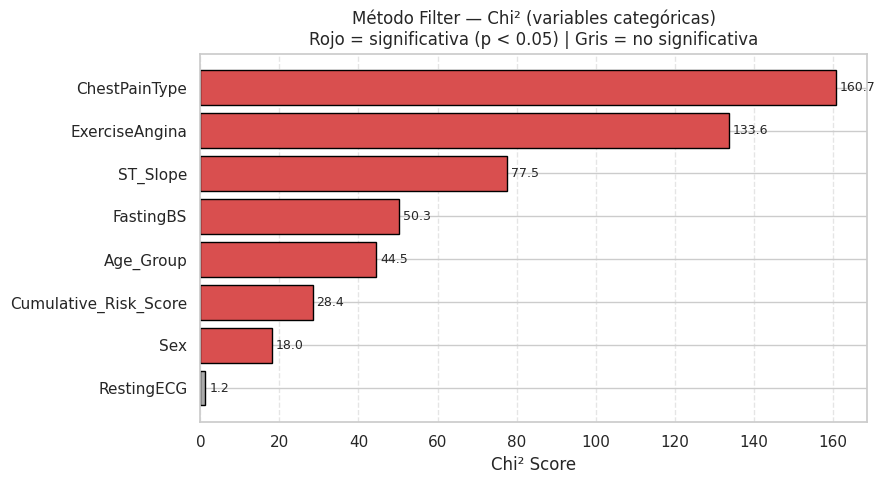

In [29]:
# Visualización
fig, ax = plt.subplots(figsize=(9, 5))
colors_chi2 = ['#D94F4F' if p < 0.05 else '#AAAAAA'
               for p in chi2_df['p_value']]
bars = ax.barh(chi2_df['Feature'][::-1], chi2_df['Chi2'][::-1],
               color=colors_chi2[::-1], edgecolor='black')
for bar, val in zip(bars, chi2_df['Chi2'][::-1]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
ax.set_xlabel('Chi² Score')
ax.set_title('Método Filter — Chi² (variables categóricas)\n'
             'Rojo = significativa (p < 0.05) | Gris = no significativa')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

ANOVA para variables númericas

In [30]:
# ── ANOVA F-value para variables numéricas ────────────────────────
anova_sel = SelectKBest(score_func=f_classif, k='all').fit(X_anova, y)

anova_df = pd.DataFrame({
    'Feature'  : num_features_anova,
    'F_score'  : anova_sel.scores_,
    'p_value'  : anova_sel.pvalues_,
    'Significativa': anova_sel.pvalues_ < 0.05
}).sort_values('F_score', ascending=False).reset_index(drop=True)

print('ANOVA F-value — Variables Numéricas:')
print(anova_df.to_string(index=False))


ANOVA F-value — Variables Numéricas:
              Feature  F_score  p_value  Significativa
Exercise_Stress_Score   208.22 1.11e-42           True
              Oldpeak   178.62 2.39e-37           True
                MaxHR   174.91 1.14e-36           True
           HR_Reserve   116.04 1.47e-25           True
                  Age    79.16 3.01e-18           True
            RestingBP    12.89 3.48e-04           True
Cholesterol_Age_Ratio    12.15 5.13e-04           True
          Cholesterol     5.34 2.11e-02           True


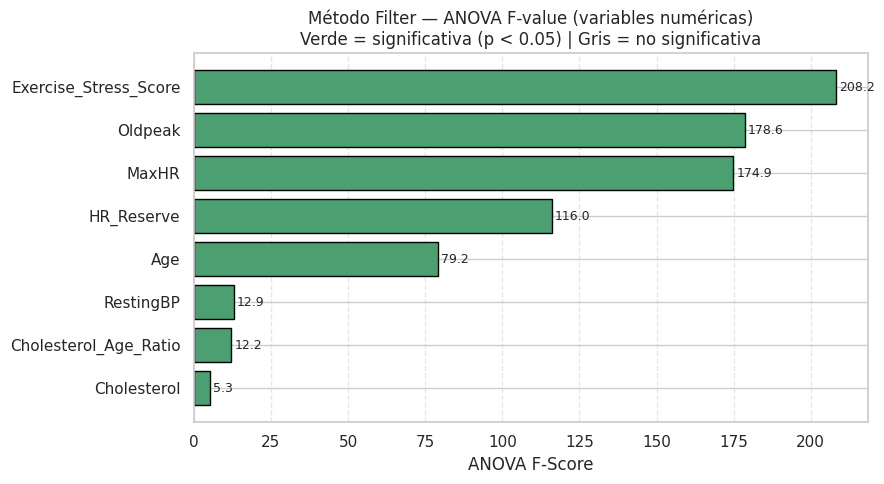

In [31]:
# Visualización
fig, ax = plt.subplots(figsize=(9, 5))
colors_anova = ['#4C9F70' if p < 0.05 else '#AAAAAA'
                for p in anova_df['p_value']]
bars = ax.barh(anova_df['Feature'][::-1], anova_df['F_score'][::-1],
               color=colors_anova[::-1], edgecolor='black')
for bar, val in zip(bars, anova_df['F_score'][::-1]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
ax.set_xlabel('ANOVA F-Score')
ax.set_title('Método Filter — ANOVA F-value (variables numéricas)\n'
             'Verde = significativa (p < 0.05) | Gris = no significativa')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Métodos Embedded

Random Forest feature importances

In [32]:
# ── Random Forest feature importances ────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_all, y)

rf_df = pd.DataFrame({
    'Feature'   : all_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Random Forest — Importancia de Features:')
print(rf_df.to_string(index=False))


Random Forest — Importancia de Features:
              Feature  Importance
             ST_Slope        0.21
        ChestPainType        0.11
              Oldpeak        0.08
                MaxHR        0.08
           HR_Reserve        0.07
       ExerciseAngina        0.07
Exercise_Stress_Score        0.06
                  Age        0.05
          Cholesterol        0.05
            RestingBP        0.05
Cholesterol_Age_Ratio        0.05
                  Sex        0.03
            FastingBS        0.02
Cumulative_Risk_Score        0.02
           RestingECG        0.02
            Age_Group        0.02


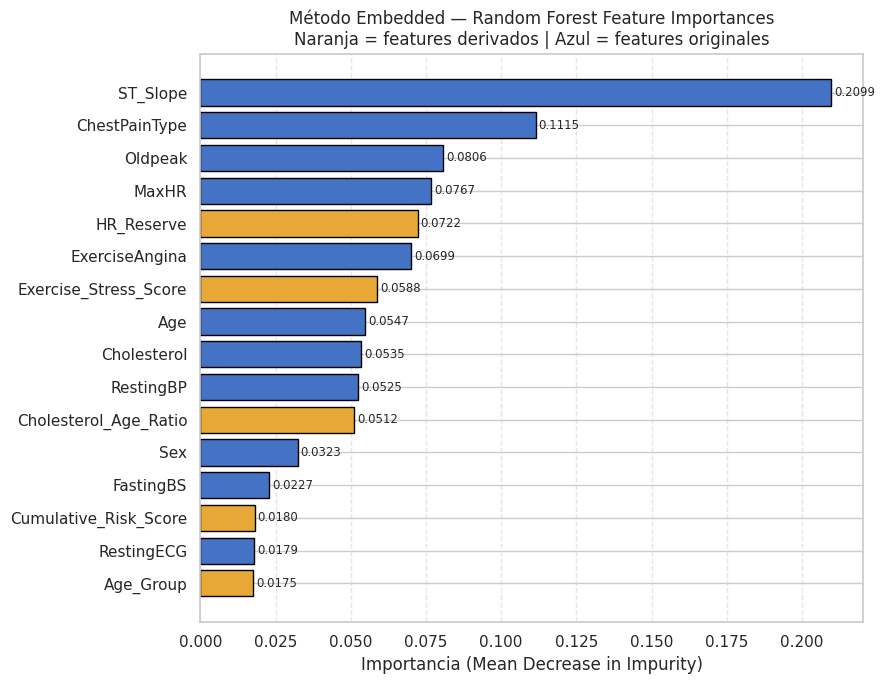

In [33]:
# Visualización
derived = ['HR_Reserve', 'Exercise_Stress_Score',
           'Cumulative_Risk_Score', 'Age_Group', 'Cholesterol_Age_Ratio']
colors_rf = ['#E8A838' if f in derived else '#4472C4'
             for f in rf_df['Feature'][::-1]]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(rf_df['Feature'][::-1], rf_df['Importance'][::-1],
               color=colors_rf, edgecolor='black')
for bar, val in zip(bars, rf_df['Importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)
ax.set_xlabel('Importancia (Mean Decrease in Impurity)')
ax.set_title('Método Embedded — Random Forest Feature Importances\n'
             'Naranja = features derivados | Azul = features originales')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Wrapper — RFE con Logistic Regression

In [34]:
# ── RFE con Logistic Regression ──────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Solo las variables NOMINALES (sin orden real) van a One-Hot.
# RestingECG, ChestPainType, ExerciseAngina, Sex y ST_Slope son nominales.
# El resto (numéricas + FastingBS binaria + las derivadas) pasan igual.
nominal_cols_all = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
resto_cols_all    = [f for f in all_features if f not in nominal_cols_all]

ohe_preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(drop='if_binary'), nominal_cols_all),
    ('scale',  StandardScaler(),                resto_cols_all)
])

# n_features_to_select=1: el RFE rankea TODAS las columnas expandidas
# hasta el final, en lugar de fijar 10 (que se interpretaría sobre las
# columnas post-One-Hot, no sobre las 16 features originales).
rfe_pipeline = Pipeline([
    ('prep', ohe_preprocessor),
    ('rfe',  RFE(estimator=LogisticRegression(max_iter=1000, random_state=42),
                 n_features_to_select=1))
])
rfe_pipeline.fit(X_all, y)

# Las columnas dummy quedan nombradas "onehot__ChestPainType_1", etc.
# Reagregamos a nivel de feature original: seleccionada si AL MENOS UNA
# de sus columnas dummy fue seleccionada por RFE.
def feature_base_name(col):
    transformer, rest = col.split('__', 1)
    if transformer == 'onehot':
        for f in nominal_cols_all:
            if rest.startswith(f + '_'):
                return f
    return rest

feature_names_ohe = ohe_preprocessor.get_feature_names_out()
rfe_step = rfe_pipeline.named_steps['rfe']

rfe_expanded_df = pd.DataFrame({
    'Feature_OHE': feature_names_ohe,
    'Ranking'    : rfe_step.ranking_
})
rfe_expanded_df['Feature'] = rfe_expanded_df['Feature_OHE'].apply(feature_base_name)

# Cada feature original se queda con el MEJOR ranking entre sus dummies
rfe_df = (rfe_expanded_df
          .groupby('Feature')['Ranking']
          .min()
          .reindex(all_features)
          .reset_index()
          .sort_values('Ranking')
          .reset_index(drop=True))

# Las 10 features ORIGINALES con mejor ranking agregado son las seleccionadas
rfe_df['Selected'] = rfe_df.index < 10

print('RFE (con One-Hot para nominales) — Ranking de Features:')
print(rfe_df.to_string(index=False))

RFE (con One-Hot para nominales) — Ranking de Features:
              Feature  Ranking  Selected
             ST_Slope        1      True
        ChestPainType        2      True
                  Sex        3      True
       ExerciseAngina        4      True
            FastingBS        6      True
              Oldpeak        7      True
            Age_Group        9      True
                MaxHR       12      True
Cholesterol_Age_Ratio       13      True
                  Age       14      True
          Cholesterol       15     False
           HR_Reserve       16     False
Exercise_Stress_Score       17     False
Cumulative_Risk_Score       18     False
           RestingECG       20     False
            RestingBP       23     False


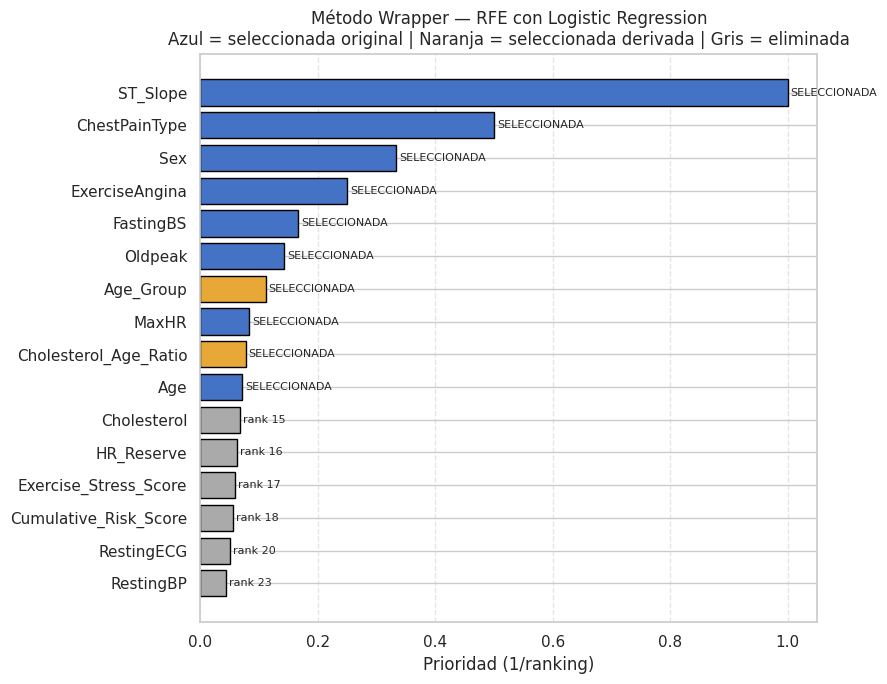

In [35]:
# Visualización
colors_rfe = []
for _, row in rfe_df[::-1].iterrows():
    if row['Selected'] and row['Feature'] in derived:
        colors_rfe.append('#E8A838')
    elif row['Selected']:
        colors_rfe.append('#4472C4')
    else:
        colors_rfe.append('#AAAAAA')

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(rfe_df['Feature'][::-1],
               [1/r for r in rfe_df['Ranking'][::-1]],
               color=colors_rfe, edgecolor='black')
for bar, row in zip(bars, rfe_df[::-1].itertuples()):
    label = 'SELECCIONADA' if row.Selected else f'rank {row.Ranking}'
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=8)
ax.set_xlabel('Prioridad (1/ranking)')
ax.set_title('Método Wrapper — RFE con Logistic Regression\n'
             'Azul = seleccionada original | Naranja = seleccionada derivada | Gris = eliminada')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Comparación final y selección de features

In [36]:
# ── Tabla de comparación de los tres métodos ─────────────────────

# Umbral filter: p < 0.05 en chi2 o anova
filter_selected = set(
    chi2_df[chi2_df['p_value'] < 0.05]['Feature'].tolist() +
    anova_df[anova_df['p_value'] < 0.05]['Feature'].tolist()
)

# Umbral embedded: importancia > promedio
rf_threshold = rf_df['Importance'].mean()
embedded_selected = set(rf_df[rf_df['Importance'] >= rf_threshold]['Feature'])

# Wrapper: features con rank=1
wrapper_selected = set(rfe_df[rfe_df['Selected']]['Feature'])

# Construir tabla comparativa
rows = []
for feat in all_features:
    en_filter   = '✅' if feat in filter_selected   else '❌'
    en_embedded = '✅' if feat in embedded_selected else '❌'
    en_wrapper  = '✅' if feat in wrapper_selected  else '❌'
    votos = sum([feat in filter_selected,
                 feat in embedded_selected,
                 feat in wrapper_selected])
    es_derivada = '⭐' if feat in derived else ''
    rows.append([feat, en_filter, en_embedded, en_wrapper, votos, es_derivada])

comparison_df = pd.DataFrame(rows, columns=[
    'Feature', 'Filter (Chi²/ANOVA)', 'Embedded (RF)', 'Wrapper (RFE)', 'Votos (de 3)', 'Derivada'
]).sort_values('Votos (de 3)', ascending=False).reset_index(drop=True)

print('TABLA COMPARATIVA DE MÉTODOS DE SELECCIÓN:')
print(comparison_df.to_string(index=False))



TABLA COMPARATIVA DE MÉTODOS DE SELECCIÓN:
              Feature Filter (Chi²/ANOVA) Embedded (RF) Wrapper (RFE)  Votos (de 3) Derivada
        ChestPainType                   ✅             ✅             ✅             3         
                MaxHR                   ✅             ✅             ✅             3         
              Oldpeak                   ✅             ✅             ✅             3         
       ExerciseAngina                   ✅             ✅             ✅             3         
             ST_Slope                   ✅             ✅             ✅             3         
            FastingBS                   ✅             ❌             ✅             2         
                  Sex                   ✅             ❌             ✅             2         
                  Age                   ✅             ❌             ✅             2         
Cholesterol_Age_Ratio                   ✅             ❌             ✅             2        ⭐
            Age_Group      

In [37]:
# Features finales: seleccionadas por al menos 2 de 3 métodos
final_features = comparison_df[comparison_df['Votos (de 3)'] >= 2]['Feature'].tolist()

print(f'\n{"="*55}')
print(f'FEATURES SELECCIONADAS (≥ 2 votos de 3): {len(final_features)}')
print(f'{"="*55}')
for f in final_features:
    tag = ' ← derivada' if f in derived else ''
    print(f'  • {f}{tag}')


FEATURES SELECCIONADAS (≥ 2 votos de 3): 11
  • ChestPainType
  • MaxHR
  • Oldpeak
  • ExerciseAngina
  • ST_Slope
  • FastingBS
  • Sex
  • Age
  • Cholesterol_Age_Ratio ← derivada
  • Age_Group ← derivada
  • HR_Reserve ← derivada


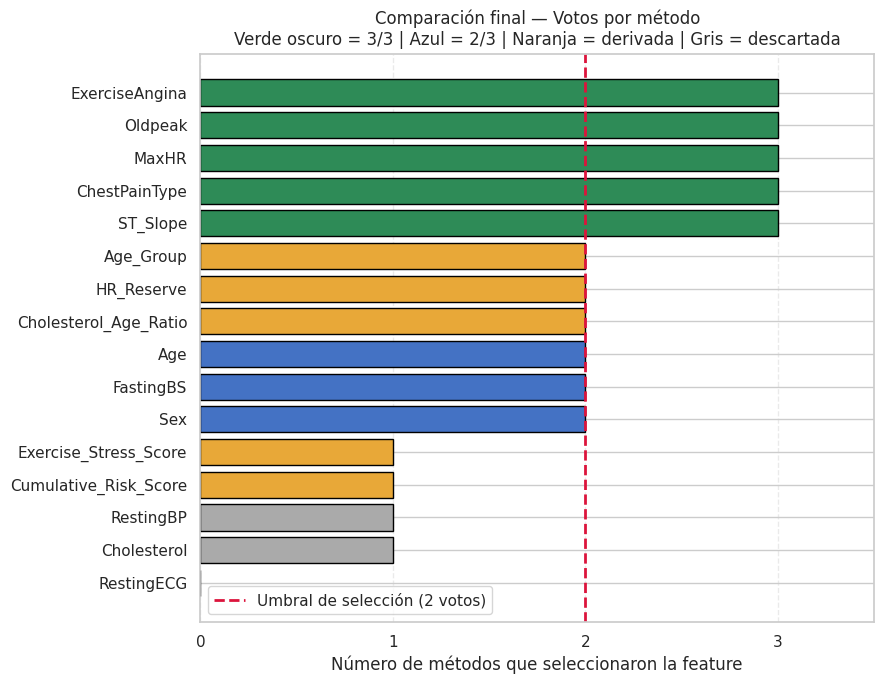

In [38]:
# Visualización de votos
fig, ax = plt.subplots(figsize=(9, 7))
vote_df = comparison_df.sort_values('Votos (de 3)', ascending=True)
colors_vote = ['#E8A838' if f in derived else
               ('#2E8B57' if v == 3 else '#4472C4' if v == 2 else '#AAAAAA')
               for f, v in zip(vote_df['Feature'], vote_df['Votos (de 3)'])]

ax.barh(vote_df['Feature'], vote_df['Votos (de 3)'],
        color=colors_vote, edgecolor='black')
ax.axvline(2, color='crimson', linestyle='--', linewidth=2,
           label='Umbral de selección (2 votos)')
ax.set_xlabel('Número de métodos que seleccionaron la feature')
ax.set_title('Comparación final — Votos por método\n'
             'Verde oscuro = 3/3 | Azul = 2/3 | Naranja = derivada | Gris = descartada')
ax.set_xlim(0, 3.5)
ax.set_xticks([0, 1, 2, 3])
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [39]:
# Guardar dataset final
X_final = df_fs[final_features]
print(f'\nDataset listo para entrenamiento: {X_final.shape}')


Dataset listo para entrenamiento: (918, 11)


In [40]:
X_final

,ChestPainType,MaxHR,Oldpeak,ExerciseAngina,ST_Slope,FastingBS,Sex,Age,Cholesterol_Age_Ratio,Age_Group,HR_Reserve
0,1,172,0.0,0,2,0,1,40,7.22,0,0.96
1,2,156,1.0,0,1,0,0,49,3.67,1,0.91
2,1,98,0.0,0,2,0,1,37,7.65,0,0.54
3,0,108,1.5,1,1,0,0,48,4.46,1,0.63
4,2,122,0.0,0,2,0,1,54,3.61,1,0.73
...,...,...,...,...,...,...,...,...,...,...,...
913,3,132,1.2,0,1,0,1,45,5.87,1,0.75
914,0,141,3.4,0,1,1,1,68,2.84,3,0.93
915,0,115,1.2,1,1,0,1,57,2.30,2,0.71
916,1,174,0.0,0,1,0,0,57,4.14,2,1.07


##Tuneo de hiperparámetros y entrenamiento de los modelos

In [41]:
# ── Separar features y target ────────────────────────────────────
# Usamos df_fs (dataset codificado) y final_features de la selección anterior

# Features finales seleccionadas (≥ 2 votos de 3 métodos)
# Resultado del paso anterior: 11 features
final_features = [
    'Age', 'Sex', 'ChestPainType', 'FastingBS',
    'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
    'HR_Reserve', 'Age_Group', 'Cholesterol_Age_Ratio'
]

X = df_fs[final_features].copy()
y = df_fs['HeartDisease'].copy()

# ── Clasificar columnas para el ColumnTransformer ────────────────
# Numéricas continuas → StandardScaler
num_cols = ['Age', 'MaxHR', 'Oldpeak', 'HR_Reserve', 'Cholesterol_Age_Ratio']

# Categóricas / discretas → passthrough (ya codificadas como int)
# se hizo aplico el labelEncoder en la selección de features
cat_cols = ['Sex', 'ChestPainType', 'FastingBS',
            'ExerciseAngina', 'ST_Slope', 'Age_Group']

print(f'Shape X: {X.shape}')
print(f'Distribución target: {dict(y.value_counts())}')
print(f'\nNuméricas  (StandardScaler)  : {num_cols}')
print(f'Categóricas (passthrough)    : {cat_cols}')

Shape X: (918, 11)
Distribución target: {1: np.int64(508), 0: np.int64(410)}

Numéricas  (StandardScaler)  : ['Age', 'MaxHR', 'Oldpeak', 'HR_Reserve', 'Cholesterol_Age_Ratio']
Categóricas (passthrough)    : ['Sex', 'ChestPainType', 'FastingBS', 'ExerciseAngina', 'ST_Slope', 'Age_Group']


Escalador

In [42]:
# ── Preprocessor: StandardScaler solo a numéricas continuas ─────
# Dos preprocessors: One-Hot para no-arbóreos (LR, SVM, KNN), passthrough para RF.
# Solo Sex, ChestPainType, ExerciseAngina y ST_Slope son nominales aquí
# (FastingBS es binaria y Age_Group es ordinal real → se mantienen passthrough).
nominal_cols = ['Sex', 'ChestPainType', 'ExerciseAngina', 'ST_Slope']

preprocessor_ohe = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(),        num_cols),
    ('onehot', OneHotEncoder(drop='if_binary'), nominal_cols)
], remainder='passthrough')   # deja pasar FastingBS y Age_Group sin tocar

preprocessor_rf = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), num_cols)
], remainder='passthrough')   # categóricas pasan como enteros (Label Encoding ya aplicado)

# Verificación: confirmar qué le llega a cada familia de modelos
print('Preprocessors configurados:')
print(f'  StandardScaler aplicado a (ambos) : {num_cols}')
print()
print('  preprocessor_ohe (LR, SVM, KNN):')
print(f'    One-Hot Encoding  : {nominal_cols}')
print(f'    Passthrough       : {[c for c in cat_cols if c not in nominal_cols]}')
print()
print('  preprocessor_rf (Random Forest):')
print(f'    Passthrough (Label Encoding ya aplicado): {cat_cols}')
print()
print('Nota: cada preprocessor se incluye DENTRO de su pipeline')
print('para evitar data leakage durante la validación cruzada.')

Preprocessors configurados:
  StandardScaler aplicado a (ambos) : ['Age', 'MaxHR', 'Oldpeak', 'HR_Reserve', 'Cholesterol_Age_Ratio']

  preprocessor_ohe (LR, SVM, KNN):
    One-Hot Encoding  : ['Sex', 'ChestPainType', 'ExerciseAngina', 'ST_Slope']
    Passthrough       : ['FastingBS', 'Age_Group']

  preprocessor_rf (Random Forest):
    Passthrough (Label Encoding ya aplicado): ['Sex', 'ChestPainType', 'FastingBS', 'ExerciseAngina', 'ST_Slope', 'Age_Group']

Nota: cada preprocessor se incluye DENTRO de su pipeline
para evitar data leakage durante la validación cruzada.


Armado de los pipelines

In [43]:
# ── Pipelines: preprocessor + modelo en un solo objeto ──────────
# Cada pipeline aplica el escalado DENTRO de cada fold de CV,
# garantizando que el test set no contamina el ajuste del scaler.

pipelines = []

# 1. Logistic Regression
# solver='liblinear': recomendado para datasets medianos en clasificación binaria
# penalty='l2': regularización Ridge, mantiene todos los coeficientes
# class_weight='balanced': ajusta pesos inversamente proporcionales a frecuencias
pipelines.append(('LR', make_pipeline(
    preprocessor_ohe,
    LogisticRegression(
        solver       = 'liblinear',
        penalty      = 'l2',
        C            = 1.0,
        class_weight = 'balanced',
        max_iter     = 1000,
        random_state = RANDOM_STATE
    )
)))

# 2. Support Vector Machine
# kernel='rbf': fronteras de decisión no lineales (gaussianas)
# gamma='scale': radio de influencia de cada SV = 1/(n_features * X.var())
# class_weight='balanced': maneja el leve desbalance 55/45
pipelines.append(('SVM', make_pipeline(
    preprocessor_ohe,
    SVC(
        kernel       = 'rbf',
        C            = 1.0,
        gamma        = 'scale',
        class_weight = 'balanced',
        random_state = RANDOM_STATE,
        probability  = True    # ← necesario para predict_proba() y curvas ROC
    )
)))

# 3. Random Forest
# n_estimators=200: por encima del umbral de convergencia (~128 árboles, Oshiro 2012)
# criterion='gini': default, equivalente a entropy en clasificación binaria
# class_weight='balanced': ajusta pesos por clase
pipelines.append(('RF', make_pipeline(
    preprocessor_rf,
    RandomForestClassifier(
        n_estimators = 200,
        criterion    = 'gini',
        class_weight = 'balanced',
        random_state = RANDOM_STATE,
        n_jobs       = -1
    )
)))

# 4. K-Nearest Neighbors
# n_neighbors=5: valor estándar de la comunidad (default sklearn)
# KNN NO tiene class_weight → el escalado previo es especialmente crítico
# porque KNN basa su decisión completamente en distancias euclidianas
pipelines.append(('KNN', make_pipeline(
    preprocessor_ohe,
    KNeighborsClassifier(
        n_neighbors = 5,
        metric      = 'euclidean'
    )
)))

print('Pipelines construidos:')
for name, pipe in pipelines:
    pasos = [type(p).__name__ for p in pipe.steps[-1][1].__class__.__mro__[:1]]
    print(f'  {name:5s} → ColumnTransformer + {type(pipe.steps[-1][1]).__name__}')

Pipelines construidos:
  LR    → ColumnTransformer + LogisticRegression
  SVM   → ColumnTransformer + SVC
  RF    → ColumnTransformer + RandomForestClassifier
  KNN   → ColumnTransformer + KNeighborsClassifier


Partición de datos

In [44]:
# ── Train / Test split estratificado ────────────────────────────
# stratify=y preserva la proporción 55/45 en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y
)

print(f'Train : {X_train.shape[0]} registros  '
      f'({y_train.mean()*100:.1f}% positivos)')
print(f'Test  : {X_test.shape[0]}  registros  '
      f'({y_test.mean()*100:.1f}% positivos)')
print()
print('El test set queda apartado y NO se usa durante la CV.')
print('Solo se usa una vez al final para la evaluación definitiva.')

Train : 734 registros  (55.3% positivos)
Test  : 184  registros  (55.4% positivos)

El test set queda apartado y NO se usa durante la CV.
Solo se usa una vez al final para la evaluación definitiva.


Validación cruzada estratificada

In [45]:
# ── Cross-validation: StratifiedKFold 5 folds ───────────────────
# StratifiedKFold garantiza que cada fold mantiene la proporción de clases
# shuffle=True: aleatoriza las muestras antes de partir en folds

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_cv = []

print(f'{"Modelo":6s}  {"Fold 1":>8} {"Fold 2":>8} {"Fold 3":>8} '
      f'{"Fold 4":>8} {"Fold 5":>8}  {"Media":>8} {"Desv.":>7}')
print('-' * 70)

for nombre, pipeline in pipelines:
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv      = cv,
        scoring = 'balanced_accuracy',
        n_jobs  = -1
    )
    resultados_cv.append({
        'Modelo'      : nombre,
        'Fold_1'      : round(scores[0], 4),
        'Fold_2'      : round(scores[1], 4),
        'Fold_3'      : round(scores[2], 4),
        'Fold_4'      : round(scores[3], 4),
        'Fold_5'      : round(scores[4], 4),
        'Media'       : round(scores.mean(), 4),
        'Desv_Est'    : round(scores.std(),  4),
        'scores_raw'  : scores
    })
    fold_str = '  '.join([f'{s:.4f}' for s in scores])
    print(f'{nombre:6s}  {fold_str}  '
          f'  {scores.mean():.4f}  {scores.std():.4f}')

df_cv = pd.DataFrame(resultados_cv).drop(columns='scores_raw')

Modelo    Fold 1   Fold 2   Fold 3   Fold 4   Fold 5     Media   Desv.
----------------------------------------------------------------------
LR      0.8361  0.7943  0.8345  0.8715  0.8490    0.8371  0.0251
SVM     0.8332  0.7825  0.8667  0.8563  0.8767    0.8431  0.0336
RF      0.8393  0.7792  0.8701  0.8673  0.8321    0.8376  0.0328
KNN     0.8300  0.7943  0.8364  0.8350  0.8259    0.8243  0.0155


Resultados obtenidos

In [46]:
# ── Tabla resumen ────────────────────────────────────────────────
print('RESUMEN DE VALIDACIÓN CRUZADA (balanced_accuracy):')
print(df_cv[['Modelo','Media','Desv_Est','Fold_1','Fold_2',
             'Fold_3','Fold_4','Fold_5']].to_string(index=False))


RESUMEN DE VALIDACIÓN CRUZADA (balanced_accuracy):
Modelo  Media  Desv_Est  Fold_1  Fold_2  Fold_3  Fold_4  Fold_5
    LR   0.84      0.03    0.84    0.79    0.83    0.87    0.85
   SVM   0.84      0.03    0.83    0.78    0.87    0.86    0.88
    RF   0.84      0.03    0.84    0.78    0.87    0.87    0.83
   KNN   0.82      0.02    0.83    0.79    0.84    0.83    0.83


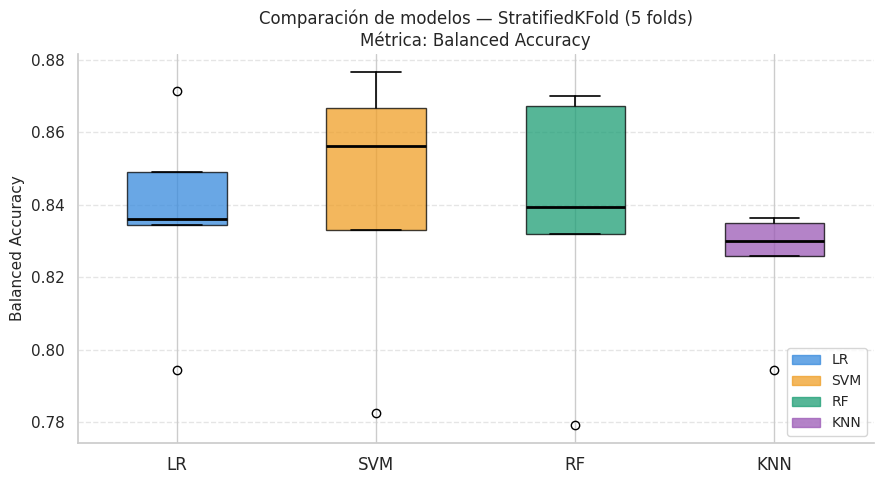

In [47]:
# ── Boxplot ──────────────────────────────────────────────────────
colores = {'LR':'#378ADD', 'SVM':'#EF9F27', 'RF':'#1D9E75', 'KNN':'#9B59B6'}
nombres = [r['Modelo'] for r in resultados_cv]
datos   = [r['scores_raw'] for r in resultados_cv]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(datos, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))

for patch, nombre in zip(bp['boxes'], nombres):
    patch.set_facecolor(colores[nombre])
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(nombres)+1))
ax.set_xticklabels(nombres, fontsize=12)
ax.set_ylabel('Balanced Accuracy', fontsize=11)
ax.set_title('Comparación de modelos — StratifiedKFold (5 folds)\n'
             'Métrica: Balanced Accuracy', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top','right']].set_visible(False)

patches = [mpatches.Patch(color=c, alpha=0.75, label=n)
           for n,c in colores.items()]
ax.legend(handles=patches, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


In [48]:
# Mejor modelo según media de CV
mejor = df_cv.loc[df_cv['Media'].idxmax(), 'Modelo']
print(f'\nMejor modelo en CV: {mejor}  '
      f'(media={df_cv.loc[df_cv["Media"].idxmax(),"Media"]:.4f})')


Mejor modelo en CV: SVM  (media=0.8431)


Tuneo de hiperparámetros

In [49]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import clone
import time

Armado de grillas de hiperparámetros para los modelos

In [50]:
# ── Grillas de hiperparámetros para cada modelo ──────────────────
# Los nombres de parámetros usan el prefijo del paso en el pipeline
# make_pipeline genera nombres automáticos en minúsculas del nombre de clase


param_grid_lr = [
    {   # Sub-grilla 1: liblinear admite l1 y l2
        'logisticregression__C'      : [0.01, 0.1, 1.0, 10.0],
       # C controla la regularización: valores bajos regularizan más;
# valores altos permiten mayor ajuste del modelo.
        'logisticregression__solver' : ['liblinear'],
        # liblinear permite probar penalización l1 y l2 en clasificación binaria.
        'logisticregression__penalty': ['l1', 'l2'],
        # l2 = default y más estable; l1 = produce sparsity
    # nota: l1 solo es compatible con solver='liblinear' o 'saga
    },
    {   # Sub-grilla 2: lbfgs solo admite l2
        'logisticregression__C'      : [0.01, 0.1, 1.0, 10.0],
        'logisticregression__solver' : ['lbfgs'],
        'logisticregression__penalty': ['l2'],
    },
]


param_grid_svm = {
    'svc__C'     : [0.1, 1.0, 10.0],
    # C controla el margen: valores mayores penalizan más los errores.
    'svc__kernel': ['linear', 'rbf'],
    # Se comparan una frontera lineal y una no lineal.
    'svc__gamma' : ['scale', 'auto'],
    # scale = 1/(n_features * X.var()) — default sklearn desde 0.22
    # auto  = 1/n_features — versión más simple
}

param_grid_rf = {
    'randomforestclassifier__n_estimators'  : [100, 200, 300],
    # 100 = PMC11471268 y default sklearn
    # 200 = valor que usamos justificado en Oshiro (2012)
    # 300 = por encima del umbral de convergencia con margen extra
    'randomforestclassifier__max_depth'     : [None, 5, 10, 20],
    # None = árboles completos (default); valores acotados = regularización
    'randomforestclassifier__min_samples_split': [2, 5],
    # 2 = default; 5 = regularización conservadora para dataset pequeño
}

param_grid_knn = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 11],
    # 3  = Kaggle notebook analizado
    # 5  = default sklearn estándar
    # 7  = valor intermedio
   # Permite comparar vecindarios pequeños, medios y más amplios.
    'kneighborsclassifier__metric'     : ['euclidean', 'manhattan'],
    # euclidean = distancia L2, usada en nuestra configuración base
    # manhattan = distancia L1, más robusta ante outliers
    'kneighborsclassifier__weights'    : ['uniform', 'distance'],
    # uniform  = todos los vecinos pesan igual (default)
    # distance = vecinos más cercanos pesan más
}

grillas = {
    'LR' : param_grid_lr,
    'SVM': param_grid_svm,
    'RF' : param_grid_rf,
    'KNN': param_grid_knn,
}

# Mostrar número total de combinaciones por modelo
def contar_combinaciones(grilla):
    if isinstance(grilla, list):
        # lista de sub-grillas: suma las combinaciones de cada sub-grilla
        return sum(
            contar_combinaciones(sub) for sub in grilla
        )
    else:
        # dict simple: producto cartesiano de valores
        n = 1
        for vals in grilla.values():
            n *= len(vals)
        return n

print('Combinaciones a evaluar por modelo:')
for nombre, grilla in grillas.items():
    n = contar_combinaciones(grilla)
    print(f'  {nombre:5s}: {n} combinaciones')

Combinaciones a evaluar por modelo:
  LR   : 12 combinaciones
  SVM  : 12 combinaciones
  RF   : 24 combinaciones
  KNN  : 16 combinaciones


Prueba de hiperparámetros

In [51]:
# ── GridSearchCV para cada modelo ────────────────────────────────
# cv inner: StratifiedKFold 5 folds para la búsqueda de hiperparámetros
# Se usa X_train (NO X_test) — el test set sigue reservado
cv_inner = StratifiedKFold(n_splits=5, shuffle=True,
                           random_state=RANDOM_STATE)

mejores_modelos  = {}
resultados_tuning = []

for nombre, pipeline in pipelines:
    print(f'\n{"="*55}')
    print(f'  Tuning: {nombre}')
    print(f'{"="*55}')

    t0 = time.time()

    gs = GridSearchCV(
        estimator  = clone(pipeline),
        param_grid = grillas[nombre],
        cv         = cv_inner,
        scoring    = 'balanced_accuracy',
        n_jobs     = -1,
        refit      = True,     # reentrena con los mejores params en X_train completo
        verbose    = 1
    )
    gs.fit(X_train, y_train)

    t1 = time.time()

    mejores_modelos[nombre] = gs.best_estimator_

    resultados_tuning.append({
        'Modelo'           : nombre,
        'Mejores params'   : gs.best_params_,
        'Mejor BA (CV)'    : round(gs.best_score_, 4),
        'Tiempo (s)'       : round(t1 - t0, 1)
    })

    print(f'  Mejores parámetros : {gs.best_params_}')
    print(f'  Mejor bal_accuracy : {gs.best_score_:.4f}')
    print(f'  Tiempo             : {t1-t0:.1f}s')


  Tuning: LR
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Mejores parámetros : {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'lbfgs'}
  Mejor bal_accuracy : 0.8482
  Tiempo             : 1.2s

  Tuning: SVM
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Mejores parámetros : {'svc__C': 10.0, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
  Mejor bal_accuracy : 0.8503
  Tiempo             : 6.5s

  Tuning: RF
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Mejores parámetros : {'randomforestclassifier__max_depth': 5, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 300}
  Mejor bal_accuracy : 0.8464
  Tiempo             : 53.7s

  Tuning: KNN
Fitting 5 folds for each of 16 candidates, totalling 80 fits
  Mejores parámetros : {'kneighborsclassifier__metric': 'euclidean', 'kneighborsclassifier__n_neighbors': 7, 'kneighborsclassifier__weights': 'unif

Comparación con entre el tuneo y la prueba base

In [52]:
# ── Tabla comparativa: sin tuning vs con tuning ──────────────────
print('COMPARACIÓN: CV base vs CV con tuning (balanced_accuracy)')
print(f'{"Modelo":6s}  {"Sin tuning (base)":>18}  {"Con tuning":>12}  {"Mejora":>8}')
print('-' * 55)

cv_outer = StratifiedKFold(n_splits=5, shuffle=True,
                           random_state=RANDOM_STATE)

for r in resultados_tuning:
    nombre = r['Modelo']

    # Score base (del paso anterior, sin tuning)
    score_base = df_cv.loc[df_cv['Modelo'] == nombre, 'Media'].values[0]

    # Score con tuning (evaluado en CV outer sobre X_train)
    score_tuning = cross_val_score(
        mejores_modelos[nombre], X_train, y_train,
        cv=cv_outer, scoring='balanced_accuracy', n_jobs=-1
    ).mean()

    mejora = score_tuning - score_base
    signo  = '+' if mejora >= 0 else ''
    print(f'{nombre:6s}  {score_base:>18.4f}  {score_tuning:>12.4f}  '
          f'{signo}{mejora:>7.4f}')

print()


COMPARACIÓN: CV base vs CV con tuning (balanced_accuracy)
Modelo   Sin tuning (base)    Con tuning    Mejora
-------------------------------------------------------
LR                  0.8371        0.8482  + 0.0111
SVM                 0.8431        0.8503  + 0.0072
RF                  0.8376        0.8464  + 0.0088
KNN                 0.8243        0.8407  + 0.0164



In [53]:
print('Mejores hiperparámetros encontrados:')
for r in resultados_tuning:
    print(f'\n  {r["Modelo"]}:')
    for k, v in r['Mejores params'].items():
        param = k.split('__')[1]
        print(f'    {param} = {v}')

Mejores hiperparámetros encontrados:

  LR:
    C = 0.1
    penalty = l2
    solver = lbfgs

  SVM:
    C = 10.0
    gamma = scale
    kernel = linear

  RF:
    max_depth = 5
    min_samples_split = 5
    n_estimators = 300

  KNN:
    metric = euclidean
    n_neighbors = 7
    weights = uniform


##Evaluación final

In [54]:
# ── Evaluación definitiva en test set ────────────────────────────
print('RESULTADOS FINALES EN TEST SET (modelos tuneados):')
print(f'{"Modelo":6s}  {"Accuracy":>10}  {"Bal. Accuracy":>14}')
print('-' * 38)

for nombre in ['LR', 'SVM', 'RF', 'KNN']:
    model = mejores_modelos[nombre]
    y_pred_t = model.predict(X_test)
    acc     = accuracy_score(y_test, y_pred_t)
    bal_acc = balanced_accuracy_score(y_test, y_pred_t)
    print(f'{nombre:6s}  {acc:>10.4f}  {bal_acc:>14.4f}')

RESULTADOS FINALES EN TEST SET (modelos tuneados):
Modelo    Accuracy   Bal. Accuracy
--------------------------------------
LR          0.8913          0.8924
SVM         0.8750          0.8741
RF          0.8587          0.8582
KNN         0.8533          0.8569


In [55]:
mejor_tuning = max(
    resultados_tuning,
    key=lambda r: balanced_accuracy_score(
        y_test, mejores_modelos[r['Modelo']].predict(X_test)
    )
)['Modelo']

y_pred = mejores_modelos[mejor_tuning].predict(X_test)

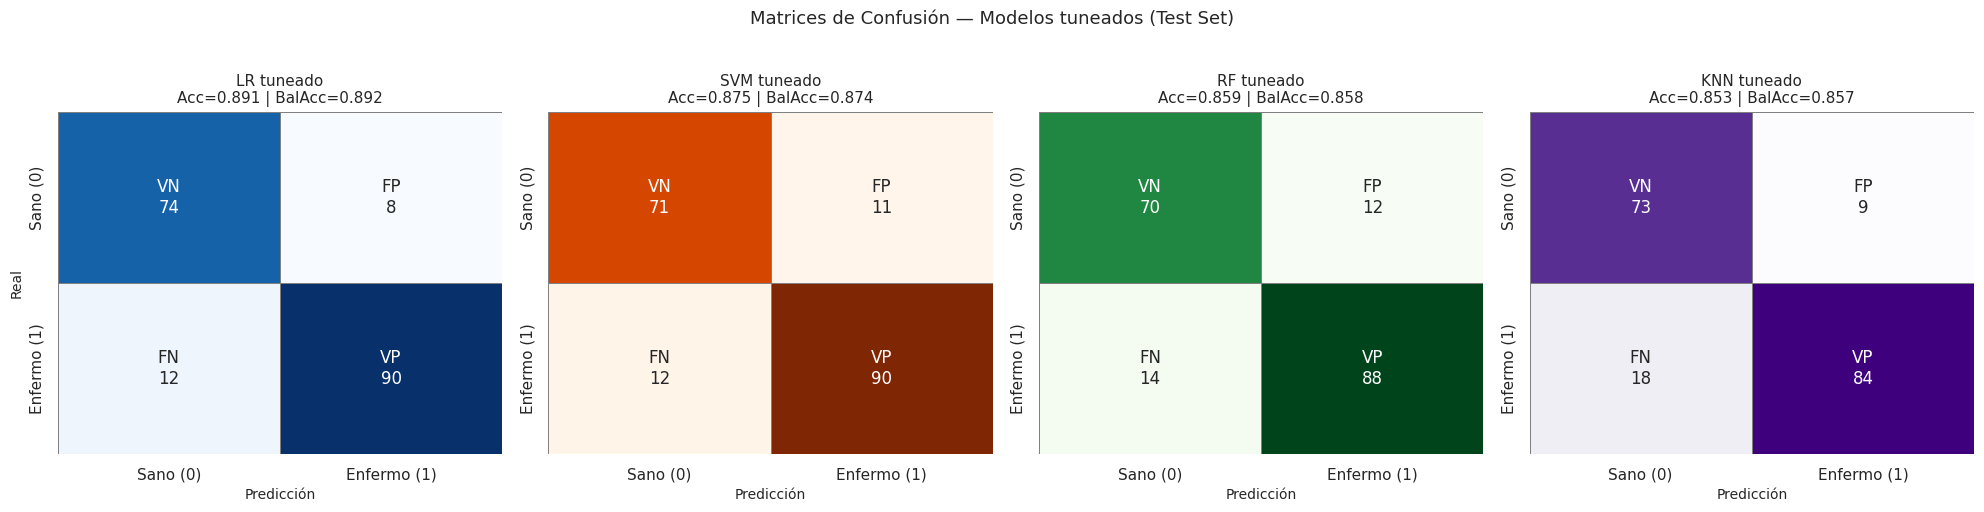


TABLA DE MÉTRICAS FINALES (Test Set):
Modelo  Accuracy  Bal_Acc  Precision  Recall  F1_Score  Especific
    LR      0.89     0.89       0.92    0.88      0.90       0.90
   SVM      0.88     0.87       0.89    0.88      0.89       0.87
    RF      0.86     0.86       0.88    0.86      0.87       0.85
   KNN      0.85     0.86       0.90    0.82      0.86       0.89

DETALLE DE ERRORES (Test Set):
Modelo  VP  VN  FP  FN
    LR  90  74   8  12
   SVM  90  71  11  12
    RF  88  70  12  14
   KNN  84  73   9  18

Modelo con menos FN (mayor Recall): LR
→ El más seguro clínicamente: detecta más enfermos reales.


In [56]:
# ── Matrices de confusión para los 4 modelos tuneados ────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

nombres_modelos = ['LR', 'SVM', 'RF', 'KNN']
colores_modelo  = {
    'LR' : 'Blues',
    'SVM': 'Oranges',
    'RF' : 'Greens',
    'KNN': 'Purples'
}

metricas_finales = []

for ax, nombre in zip(axes, nombres_modelos):

    model   = mejores_modelos[nombre]
    y_pred_m = model.predict(X_test)
    cm      = confusion_matrix(y_test, y_pred_m)

    # Valores de la matriz con etiquetas
    labels_cm = np.array([
        [f'VN\n{cm[0,0]}', f'FP\n{cm[0,1]}'],
        [f'FN\n{cm[1,0]}', f'VP\n{cm[1,1]}']
    ])

    sns.heatmap(
        cm,
        annot    = labels_cm,
        fmt      = '',
        cmap     = colores_modelo[nombre],
        ax       = ax,
        xticklabels = ['Sano (0)', 'Enfermo (1)'],
        yticklabels = ['Sano (0)', 'Enfermo (1)'],
        linewidths  = 0.5,
        linecolor   = 'gray',
        cbar        = False
    )

    acc     = accuracy_score(y_test, y_pred_m)
    bal_acc = balanced_accuracy_score(y_test, y_pred_m)

    ax.set_title(f'{nombre} tuneado\nAcc={acc:.3f} | BalAcc={bal_acc:.3f}',
                 fontsize=11)
    ax.set_xlabel('Predicción', fontsize=10)
    ax.set_ylabel('Real' if nombre == 'LR' else '', fontsize=10)

    # Calcular métricas adicionales desde la matriz
    vn, fp = cm[0, 0], cm[0, 1]
    fn, vp = cm[1, 0], cm[1, 1]

    precision = vp / (vp + fp) if (vp + fp) > 0 else 0
    recall    = vp / (vp + fn) if (vp + fn) > 0 else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0)
    especif   = vn / (vn + fp) if (vn + fp) > 0 else 0

    metricas_finales.append({
        'Modelo'    : nombre,
        'Accuracy'  : round(acc, 4),
        'Bal_Acc'   : round(bal_acc, 4),
        'Precision' : round(precision, 4),
        'Recall'    : round(recall, 4),
        'F1_Score'  : round(f1, 4),
        'Especific' : round(especif, 4),
        'VP'        : vp,
        'VN'        : vn,
        'FP'        : fp,
        'FN'        : fn
    })

plt.suptitle('Matrices de Confusión — Modelos tuneados (Test Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Tabla de métricas completa ────────────────────────────────────
df_metricas = pd.DataFrame(metricas_finales)

print('\nTABLA DE MÉTRICAS FINALES (Test Set):')
print(df_metricas[['Modelo','Accuracy','Bal_Acc','Precision',
                   'Recall','F1_Score','Especific']].to_string(index=False))

print('\nDETALLE DE ERRORES (Test Set):')
print(df_metricas[['Modelo','VP','VN','FP','FN']].to_string(index=False))

# Modelo con menos FN (más importante clínicamente)
mejor_recall = df_metricas.loc[df_metricas['Recall'].idxmax(), 'Modelo']
print(f'\nModelo con menos FN (mayor Recall): {mejor_recall}')
print('→ El más seguro clínicamente: detecta más enfermos reales.')

Comparación de los resultados de los modelos

In [57]:
from sklearn.metrics import classification_report

# ── Reporte de clasificación para cada modelo tuneado ────────────
nombres_modelos = ['LR', 'SVM', 'RF', 'KNN']

for nombre in nombres_modelos:
    model    = mejores_modelos[nombre]
    y_pred_r = model.predict(X_test)

    print(f'\n{"="*55}')
    print(f'  REPORTE DE CLASIFICACIÓN — {nombre} (tuneado)')
    print(f'{"="*55}')
    print(classification_report(
        y_test, y_pred_r,
        target_names = ['Sin enfermedad (0)', 'Con enfermedad (1)'],
        digits       = 4
    ))


  REPORTE DE CLASIFICACIÓN — LR (tuneado)
                    precision    recall  f1-score   support

Sin enfermedad (0)     0.8605    0.9024    0.8810        82
Con enfermedad (1)     0.9184    0.8824    0.9000       102

          accuracy                         0.8913       184
         macro avg     0.8894    0.8924    0.8905       184
      weighted avg     0.8926    0.8913    0.8915       184


  REPORTE DE CLASIFICACIÓN — SVM (tuneado)
                    precision    recall  f1-score   support

Sin enfermedad (0)     0.8554    0.8659    0.8606        82
Con enfermedad (1)     0.8911    0.8824    0.8867       102

          accuracy                         0.8750       184
         macro avg     0.8733    0.8741    0.8737       184
      weighted avg     0.8752    0.8750    0.8751       184


  REPORTE DE CLASIFICACIÓN — RF (tuneado)
                    precision    recall  f1-score   support

Sin enfermedad (0)     0.8333    0.8537    0.8434        82
Con enfermedad (1)     

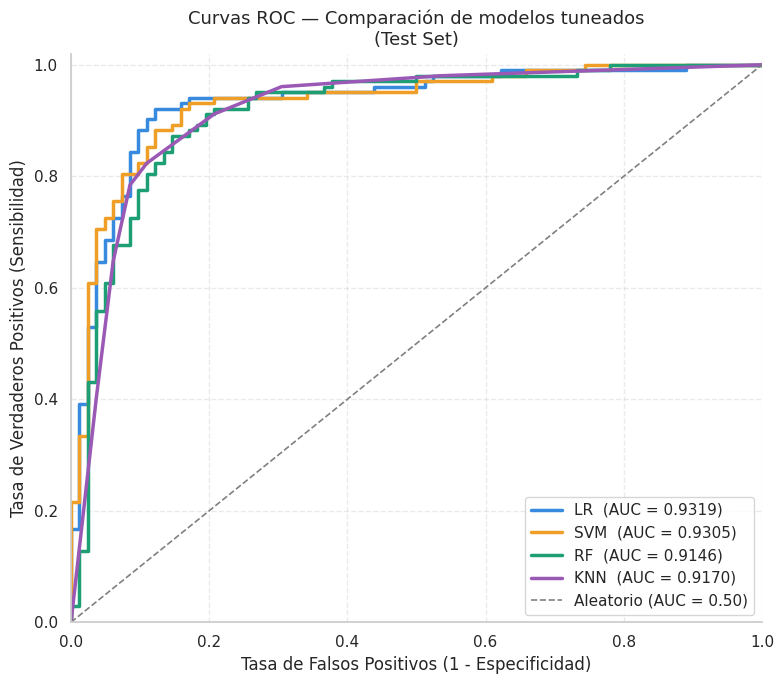

In [58]:
from sklearn.metrics import roc_curve, auc as auc_score

# ── Curvas ROC para los 4 modelos tuneados ───────────────────────
# predict_proba devuelve probabilidades para cada clase
# usamos la columna [:, 1] = probabilidad de la clase positiva (enfermedad)

colores_roc = {
    'LR' : '#378ADD',
    'SVM': '#EF9F27',
    'RF' : '#1D9E75',
    'KNN': '#9B59B6'
}

fig, ax = plt.subplots(figsize=(8, 7))

for nombre in nombres_modelos:
    model     = mejores_modelos[nombre]
    y_prob    = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc   = auc_score(fpr, tpr)

    ax.plot(fpr, tpr,
            color     = colores_roc[nombre],
            linewidth = 2.5,
            label     = f'{nombre}  (AUC = {roc_auc:.4f})')

# Línea diagonal — clasificador aleatorio (AUC = 0.5)
ax.plot([0, 1], [0, 1],
        color     = 'gray',
        linestyle = '--',
        linewidth = 1.2,
        label     = 'Aleatorio (AUC = 0.50)')

ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
ax.set_title('Curvas ROC — Comparación de modelos tuneados\n(Test Set)',
             fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(linestyle='--', alpha=0.4)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [59]:
# ── Tabla resumen: todos los modelos, todas las métricas ─────────
from sklearn.metrics import roc_auc_score

filas = []
for nombre in nombres_modelos:
    model     = mejores_modelos[nombre]
    y_pred_f  = model.predict(X_test)
    y_prob_f  = model.predict_proba(X_test)[:, 1]

    cm_f      = confusion_matrix(y_test, y_pred_f)
    vn, fp    = cm_f[0, 0], cm_f[0, 1]
    fn, vp    = cm_f[1, 0], cm_f[1, 1]

    precision = vp / (vp + fp) if (vp + fp) > 0 else 0
    recall    = vp / (vp + fn) if (vp + fn) > 0 else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0)
    especif   = vn / (vn + fp) if (vn + fp) > 0 else 0
    auc_val   = roc_auc_score(y_test, y_prob_f)

    filas.append({
        'Modelo'    : nombre,
        'Accuracy'  : round(accuracy_score(y_test, y_pred_f), 4),
        'Bal.Acc'   : round(balanced_accuracy_score(y_test, y_pred_f), 4),
        'Precision' : round(precision, 4),
        'Recall'    : round(recall, 4),
        'F1-Score'  : round(f1, 4),
        'Especif.'  : round(especif, 4),
        'AUC-ROC'   : round(auc_val, 4),
        'FN'        : fn   # el más crítico clínicamente
    })

df_final = pd.DataFrame(filas)

print('TABLA RESUMEN FINAL — Test Set (modelos tuneados):')
print(df_final.to_string(index=False))



TABLA RESUMEN FINAL — Test Set (modelos tuneados):
Modelo  Accuracy  Bal.Acc  Precision  Recall  F1-Score  Especif.  AUC-ROC  FN
    LR      0.89     0.89       0.92    0.88      0.90      0.90     0.93  12
   SVM      0.88     0.87       0.89    0.88      0.89      0.87     0.93  12
    RF      0.86     0.86       0.88    0.86      0.87      0.85     0.91  14
   KNN      0.85     0.86       0.90    0.82      0.86      0.89     0.92  18


In [60]:
# ── Ranking por cada métrica ──────────────────────────────────────
print('\nRANKING POR MÉTRICA (1 = mejor):')
metricas_rank = ['Accuracy','Bal.Acc','Recall','F1-Score','AUC-ROC']
df_rank = df_final[['Modelo'] + metricas_rank].copy()

for col in metricas_rank:
    df_rank[col] = df_rank[col].rank(ascending=False).astype(int)

# Para FN: menor es mejor
df_rank['FN (menor=mejor)'] = df_final['FN'].rank(ascending=True).astype(int)

print(df_rank.to_string(index=False))


RANKING POR MÉTRICA (1 = mejor):
Modelo  Accuracy  Bal.Acc  Recall  F1-Score  AUC-ROC  FN (menor=mejor)
    LR         1        1       1         1        1                 1
   SVM         2        2       1         2        2                 1
    RF         3        3       3         3        4                 3
   KNN         4        4       4         4        3                 4


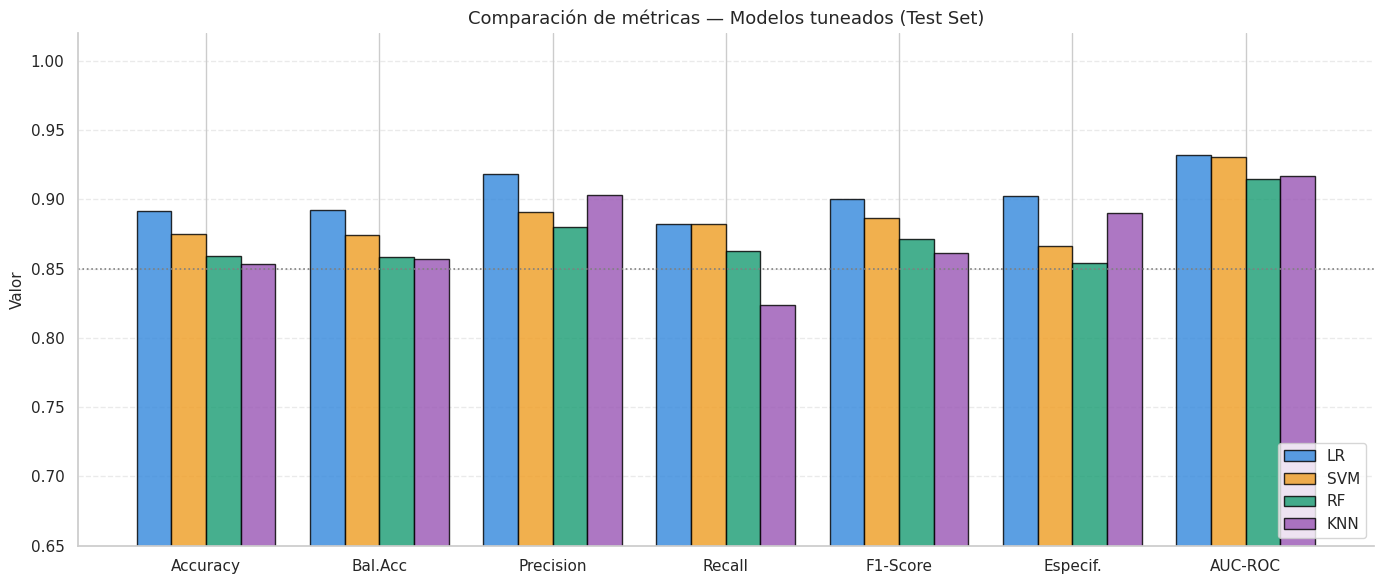

In [61]:
# ── Visualización comparativa de métricas ────────────────────────
metricas_plot = ['Accuracy', 'Bal.Acc', 'Precision', 'Recall',
                 'F1-Score', 'Especif.', 'AUC-ROC']

x     = np.arange(len(metricas_plot))
width = 0.2
fig, ax = plt.subplots(figsize=(14, 6))

for i, nombre in enumerate(nombres_modelos):
    vals = [df_final.loc[df_final['Modelo']==nombre, m].values[0]
            for m in metricas_plot]
    bars = ax.bar(x + i * width, vals, width,
                  label  = nombre,
                  color  = list(colores_roc.values())[i],
                  edgecolor = 'black',
                  alpha  = 0.82)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metricas_plot, fontsize=11)
ax.set_ylabel('Valor', fontsize=11)
ax.set_ylim(0.65, 1.02)
ax.set_title('Comparación de métricas — Modelos tuneados (Test Set)',
             fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

# Línea de referencia en 0.85
ax.axhline(0.85, color='gray', linestyle=':', linewidth=1.2,
           label='Referencia 0.85')

plt.tight_layout()
plt.show()



In [62]:
# ── Conclusión automática ─────────────────────────────────────────
mejor_auc    = df_final.loc[df_final['AUC-ROC'].idxmax(), 'Modelo']
mejor_recall = df_final.loc[df_final['Recall'].idxmax(), 'Modelo']
menor_fn     = df_final.loc[df_final['FN'].idxmin(), 'Modelo']

print(f'\nCONCLUSIONES DEL TEST SET:')
print(f'  Mayor AUC-ROC              : {mejor_auc}')
print(f'  Mayor Recall               : {mejor_recall}')
print(f'  Menos Falsos Negativos (FN): {menor_fn}')
print(f'\n  → Para aplicación clínica se prioriza el modelo con')
print(f'    mayor Recall y menor FN: {menor_fn}')
print(f'    porque minimiza el riesgo de no detectar enfermos reales.')


CONCLUSIONES DEL TEST SET:
  Mayor AUC-ROC              : LR
  Mayor Recall               : LR
  Menos Falsos Negativos (FN): LR

  → Para aplicación clínica se prioriza el modelo con
    mayor Recall y menor FN: LR
    porque minimiza el riesgo de no detectar enfermos reales.


### Resumen del pipeline implementado

Este notebook implementó un pipeline completo de aprendizaje automático para la predicción de enfermedad cardíaca utilizando el dataset Heart Failure Prediction, compuesto por 918 registros y 11 variables clínicas originales.

El flujo desarrollado siguió las siguientes etapas:

**1. Carga e imputación de datos**
Se cargó el dataset desde el repositorio de GitHub del proyecto. Luego, se identificaron 172 registros con Cholesterol = 0 y 1 registro con RestingBP = 0, valores fisiológicamente imposibles que fueron tratados como datos faltantes enmascarados e imputados mediante la mediana de los valores válidos. Los valores negativos de Oldpeak se conservaron por ser clínicamente interpretables como elevación del segmento ST.

**2. Análisis exploratorio de datos**
Se revisó la distribución de las variables, la proporción de clases y la relación de los principales predictores con la variable objetivo. Este análisis permitió identificar variables relevantes como ST_Slope, ChestPainType, ExerciseAngina, Oldpeak y MaxHR, además de evidenciar el leve desbalance de clases del dataset.

**3. Feature engineering**
A partir de las variables originales se construyeron cinco variables derivadas con respaldo bibliográfico: HR_Reserve, Exercise_Stress_Score, Cumulative_Risk_Score, Age_Group y Cholesterol_Age_Ratio. Tras el proceso de selección, tres variables derivadas quedaron dentro del conjunto final: HR_Reserve, Age_Group y Cholesterol_Age_Ratio.

**4. Selección híbrida de features**
Se aplicó un enfoque híbrido compuesto por tres métodos: Filter, mediante pruebas estadísticas; Embedded, mediante importancias de Random Forest; y Wrapper, mediante RFE con Regresión Logística. Se conservaron las variables seleccionadas por al menos dos de los tres métodos, obteniendo un conjunto final de 11 features.

**5. Construcción de pipelines**
Se construyeron pipelines independientes para cada familia de modelos. Para Regresión Logística, SVM y KNN se utilizó One-Hot Encoding en variables nominales y StandardScaler en variables numéricas continuas. Para Random Forest se mantuvo la codificación mediante Label Encoding y también se aplicó StandardScaler por consistencia operativa del pipeline, aunque este escalado no es determinante para modelos basados en árboles.

**6. Validación cruzada y tuneo de hiperparámetros**
Los modelos base se evaluaron mediante StratifiedKFold de 5 folds usando Balanced Accuracy como métrica principal. Luego, se aplicó GridSearchCV sobre el conjunto de entrenamiento para ajustar los hiperparámetros de LR, SVM, RF y KNN, manteniendo el conjunto de prueba reservado hasta la evaluación final.

**7. Evaluación final**
Los modelos tuneados se evaluaron una única vez sobre el conjunto de prueba. Regresión Logística obtuvo el mejor desempeño global, con Accuracy de 0.89, Balanced Accuracy de 0.89, Recall de 0.88, F1-Score de 0.90, AUC-ROC de 0.93 y 12 falsos negativos. SVM presentó resultados cercanos, mientras que RF y KNN quedaron por debajo en desempeño clínico. En conjunto, los cuatro modelos superaron el umbral de 0.85 de exactitud, confirmando la viabilidad del enfoque propuesto.

**8. Conclusión del notebook**
El mejor modelo final fue Regresión Logística, ya que combinó alto desempeño predictivo, menor cantidad de falsos negativos, bajo costo computacional e interpretabilidad. Los resultados sugieren que la calidad del preprocesamiento, el feature engineering y la selección de variables tuvo mayor impacto que la complejidad del algoritmo.
